# Assignment 3 - Diabetes Risk Prediction

## Intelligent System Development

This notebook follows the same report structure as the HousePrice assignment:

**Data → Understanding → Cleaning → Preprocessing → Models → Evaluation → Comparison → Deployment → Conclusion**

The notebook compares **three traditional Machine Learning models** with **one Deep Learning model implemented from scratch using NumPy**.

### Dataset

- Target: `Diabetes_Risk`
- Problem type: multi-class classification
- Classes: `Low`, `Moderate`, `High`
- Raw dataset: 50,000 patients and 41 columns, around 13MB
- Source: https://www.kaggle.com/code/hosseinbadrnezhad/diabetes-risk-prediction-dataset-50k-patients-etl
### Four models to compare

1. Logistic Regression
2. Random Forest Classifier
3. HistGradientBoosting Classifier
4. Deep Neural Network built from scratch with NumPy

All four final models are evaluated on the same untouched test set.


## 1. Learning Objectives

By the end of this notebook we should be able to:

1. Understand the structure and target of the diabetes-risk dataset.
2. Detect missing values, duplicates, invalid data, outliers, and class imbalance.
3. Remove identifier and leakage-prone columns before modeling.
4. Build meaningful engineered features and a leakage-safe numerical representation.
5. Train and compare three traditional Machine Learning classifiers.
6. Explain and implement the main Deep Learning steps from scratch with NumPy.
7. Evaluate all four models with consistent classification metrics.
8. Compare the selected ML and Deep Learning models for deployment.
9. Save model artifacts so Web and Mobile applications can perform inference without retraining.


## 2. Why Is This a Classification Problem?

The target variable `Diabetes_Risk` contains three discrete classes:

```text
Low
Moderate
High
```

Therefore this is a **multi-class classification problem**.

The model learns:

```text
Patient features → predicted risk class + class probabilities
```

Because the classes are imbalanced, **Macro Precision, Macro Recall, Macro F1, and multiclass ROC-AUC** are emphasized alongside accuracy.


# 3. Imports and Reproducibility


In [31]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif, SelectPercentile
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.base import clone
import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("data/diabetes_risk_prediction_dataset.csv")
MODEL_DIR = Path("model")
FIG_DIR = MODEL_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Model directory:", MODEL_DIR)

Data path: data\diabetes_risk_prediction_dataset.csv
Model directory: model


# 4. Locate and Load the Dataset

The raw CSV is loaded first and kept unchanged.

The modeling flow is:

**Raw data → cleaned data → engineered features → encoded representation → model input**


In [32]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find {DATA_PATH}. "
        "Place diabetes_risk_prediction_dataset.csv inside the data/ folder."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (50000, 41)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


## 4.1 Initial Dataset Observations

The dataset contains 50,000 observations and 41 columns. One row represents one patient.

`Diabetes_Risk` is the prediction target. Columns that are identifiers, recommendations, or target-derived outputs are excluded before modeling.


In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
display(pd.DataFrame({"Feature": df.columns}))

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df["Diabetes_Risk"].value_counts().to_frame("count"))

print("\nTarget percentage:")
display((df["Diabetes_Risk"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))

Rows: 50000
Columns: 41

Column names:


,Feature
0,Patient_ID
1,Age
2,Gender
3,Country
4,Height_cm
5,Weight_kg
6,BMI
7,Waist_Circumference_cm
8,Blood_Glucose
9,HbA1c



Data types:


,dtype
Patient_ID,int64
Age,float64
Gender,str
Country,str
Height_cm,float64
Weight_kg,float64
BMI,float64
Waist_Circumference_cm,float64
Blood_Glucose,float64
HbA1c,float64



Target distribution:


,count
Diabetes_Risk,
High,36593
Moderate,12937
Low,470



Target percentage:


,percentage
Diabetes_Risk,
High,73.19
Moderate,25.87
Low,0.94


# 5. Data Quality Audit

The audit checks:

1. Data types
2. Missing values
3. Duplicate rows
4. Invalid values
5. Outliers
6. Target imbalance

Missing values are handled by training-only preprocessing so the same transformation can be reused during deployment.


In [34]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

display(missing_report[missing_report["missing_count"] > 0])

print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

,missing_count,missing_percent
Weight_kg,2962,5.92
Height_cm,2945,5.89
Sleep_Hours,2017,4.03
Exercise_Hours_Per_Week,1992,3.98
HbA1c,1974,3.95
Daily_Walking_Minutes,1964,3.93
HDL,1000,2.00
LDL,1000,2.00
Triglycerides,1000,2.00
Medication_Adherence,1000,2.00


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49503.0,NaN,NaN,NaN,53.871099,21.130148,18.0,35.0,54.0,72.0,90.0
Gender,50000,3,Male,16718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,25,Malaysia,2083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,47055.0,NaN,NaN,NaN,170.018814,14.457787,145.0,157.6,170.0,182.6,195.0
Weight_kg,47038.0,NaN,NaN,NaN,87.457003,24.500358,45.0,66.3,87.3,108.6,130.0
BMI,50000.0,NaN,NaN,NaN,30.924056,10.290091,11.9,22.7,30.0,37.8,61.7
Waist_Circumference_cm,50000.0,NaN,NaN,NaN,99.96079,23.086579,60.0,80.0,99.8,119.9,140.0
Blood_Glucose,49041.0,NaN,NaN,NaN,159.905245,52.040575,70.0,114.7,159.9,205.1,250.0
HbA1c,48026.0,NaN,NaN,NaN,8.488061,2.313758,4.5,6.5,8.5,10.5,12.5


## Target Distribution and Class Imbalance

The target is strongly imbalanced, with `High` occurring much more often than `Low`.

Accuracy alone can therefore hide weak minority-class performance. Macro-averaged metrics are used to give all three risk classes equal importance.


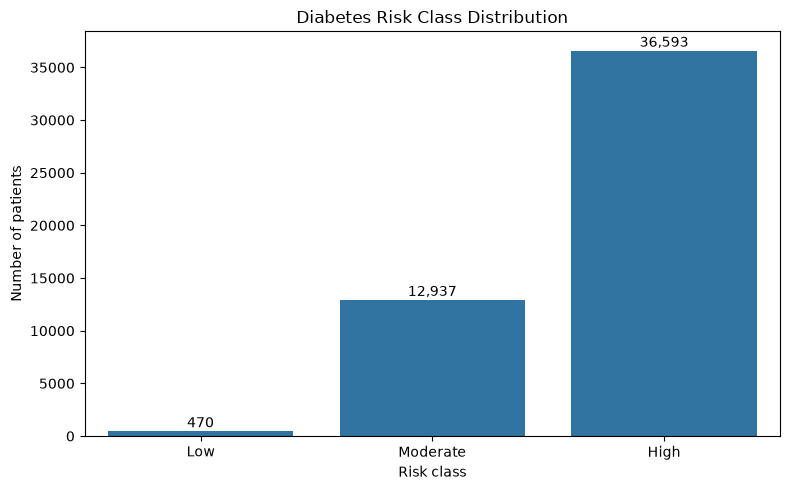

In [35]:
target_counts = df["Diabetes_Risk"].value_counts().reindex(["Low", "Moderate", "High"])

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_counts.index, y=target_counts.values)
ax.set_title("Diabetes Risk Class Distribution")
ax.set_xlabel("Risk class")
ax.set_ylabel("Number of patients")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + max(target_counts.values) * 0.01, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=180)
plt.show()

# 6. Data Type Cleaning and Feature Engineering

Before modeling, identifier/leakage-prone columns are removed and two interpretable derived variables are added.

### Engineered features

$$
PulsePressure = Systolic - Diastolic
$$

$$
CholHDLRatio = TotalCholesterol / HDL
$$

Feature engineering is deterministic and does not learn parameters from the data.


In [36]:
LEAKAGE_OR_IRRELEVANT = [
    "Patient_ID",
    "Diabetes_Risk_Score",
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed",
    "Diabetes_Risk",
]

candidate_features = [c for c in df.columns if c not in LEAKAGE_OR_IRRELEVANT]

print("Candidate feature count:", len(candidate_features))
print(candidate_features)


Candidate feature count: 36
['Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L']


In [37]:
def add_engineered_features(data):
    data = data.copy()

    if {"Blood_Pressure_Systolic", "Blood_Pressure_Diastolic"}.issubset(data.columns):
        data["Pulse_Pressure"] = (
            data["Blood_Pressure_Systolic"] - data["Blood_Pressure_Diastolic"]
        )

    if {"Total_Cholesterol", "HDL"}.issubset(data.columns):
        data["Chol_HDL_Ratio"] = (
            data["Total_Cholesterol"] / data["HDL"].replace(0, np.nan)
        )

    return data

df_model = add_engineered_features(df[candidate_features])

print("Feature count after engineering:", df_model.shape[1])
display(df_model.head())


Feature count after engineering: 38


,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Pulse_Pressure,Chol_HDL_Ratio
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,No,Yes,Yes,No,Good,Retired,Rural,4.4,33,3.458853
1,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,...,No,Yes,Yes,Yes,Average,Government,Rural,2.1,48,8.056180
2,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,...,No,No,Yes,No,Average,Government,Urban,2.8,-7,4.031153
3,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,217.7,...,Yes,No,No,No,Average,Business,Rural,1.5,57,2.717286
4,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,153.5,...,Yes,Yes,Yes,Yes,Poor,Private,Rural,1.6,100,7.526738


# 7. Exploratory Data Analysis

EDA is performed before final modeling to understand feature distributions, relationships, and possible redundancy.

The analysis uses the engineered modeling table while keeping the target separate.


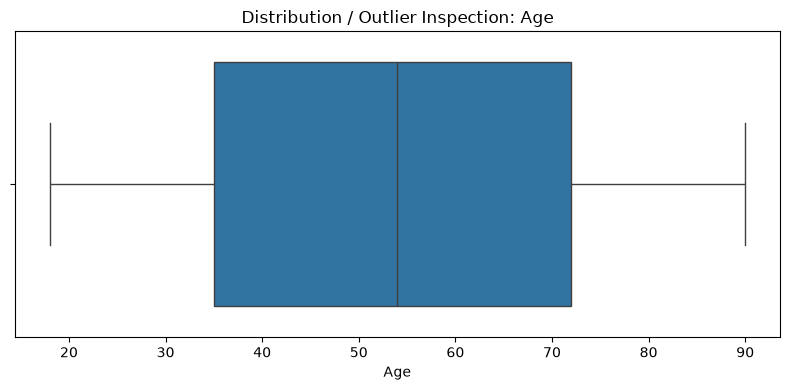

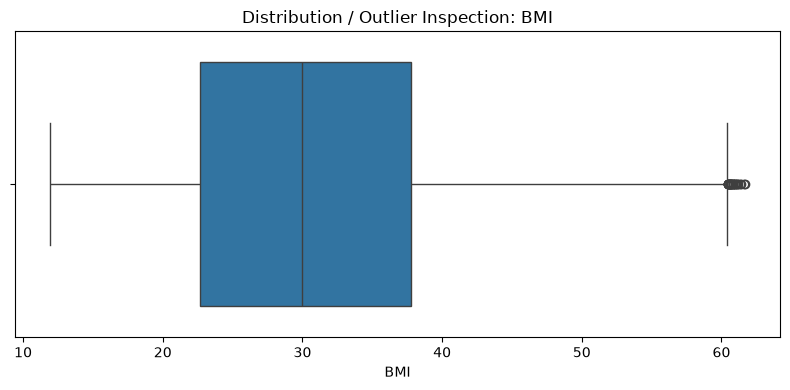

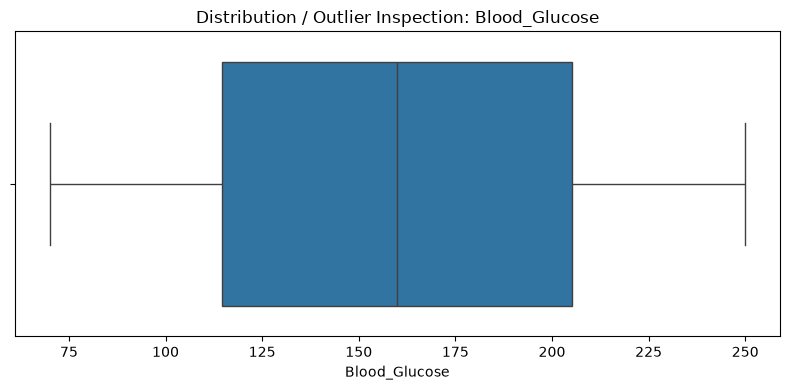

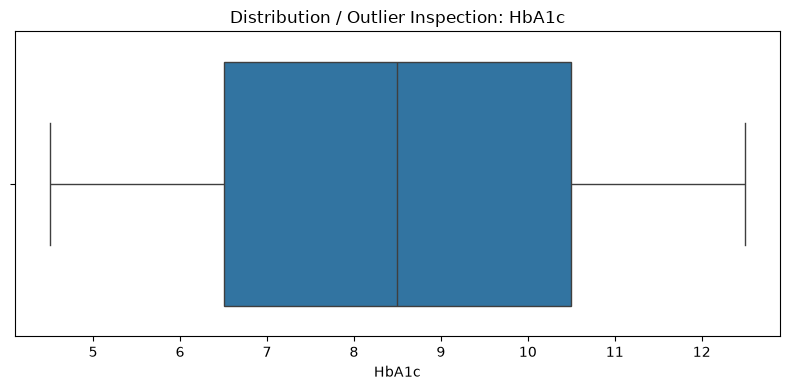

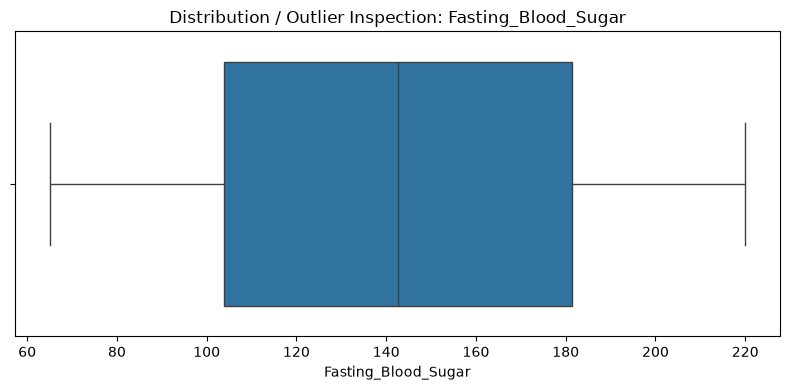

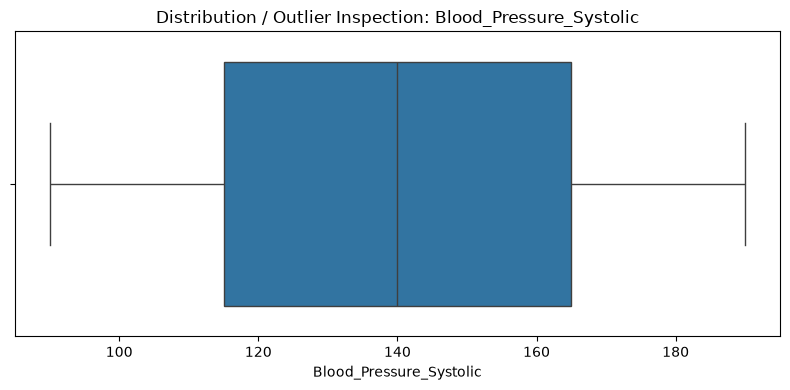

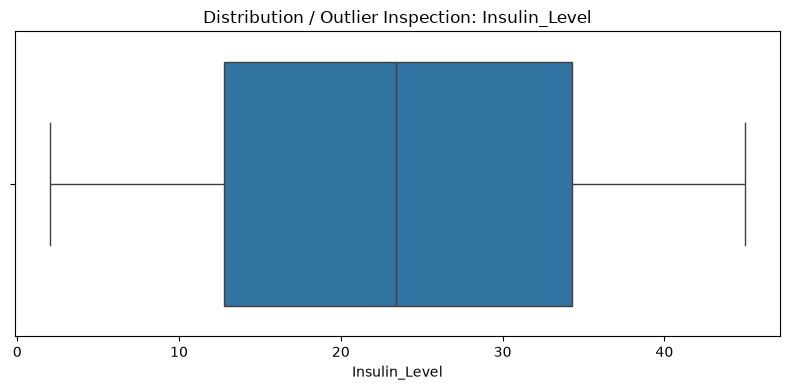

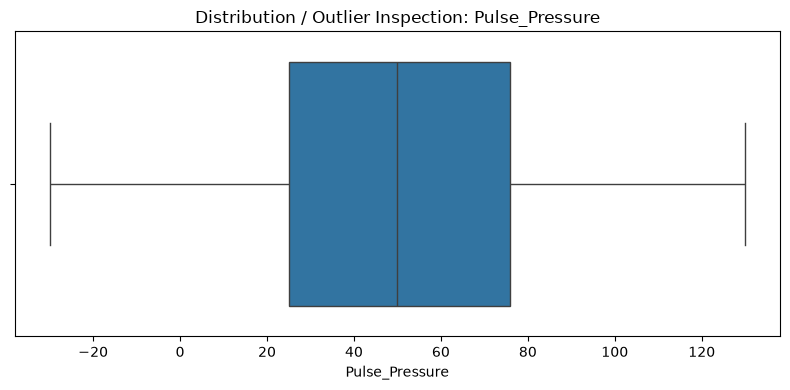

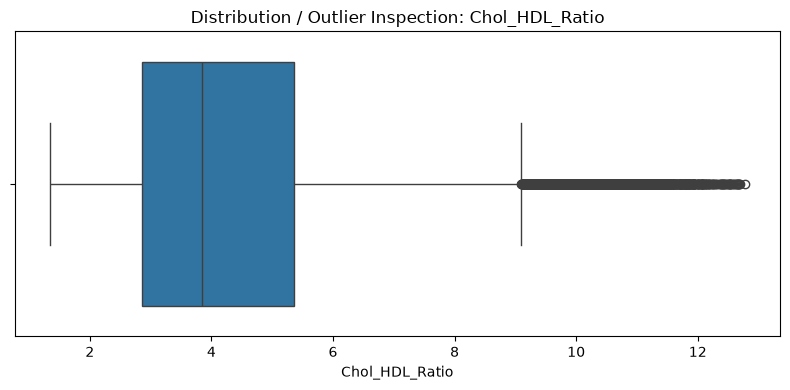

In [38]:
important_numeric = [
    c for c in [
        "Age",
        "BMI",
        "Blood_Glucose",
        "HbA1c",
        "Fasting_Blood_Sugar",
        "Blood_Pressure_Systolic",
        "Insulin_Level",
        "Pulse_Pressure",
        "Chol_HDL_Ratio",
    ]
    if c in df_model.columns
]

for col in important_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_model[col])
    plt.title(f"Distribution / Outlier Inspection: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    safe = col.lower().replace("/", "_")
    plt.savefig(FIG_DIR / f"02_boxplot_{safe}.png", dpi=160)
    plt.show()


### Numerical Correlation Analysis

Correlation is used as a supporting signal for redundant numerical information. It is not treated as the only feature-selection rule.


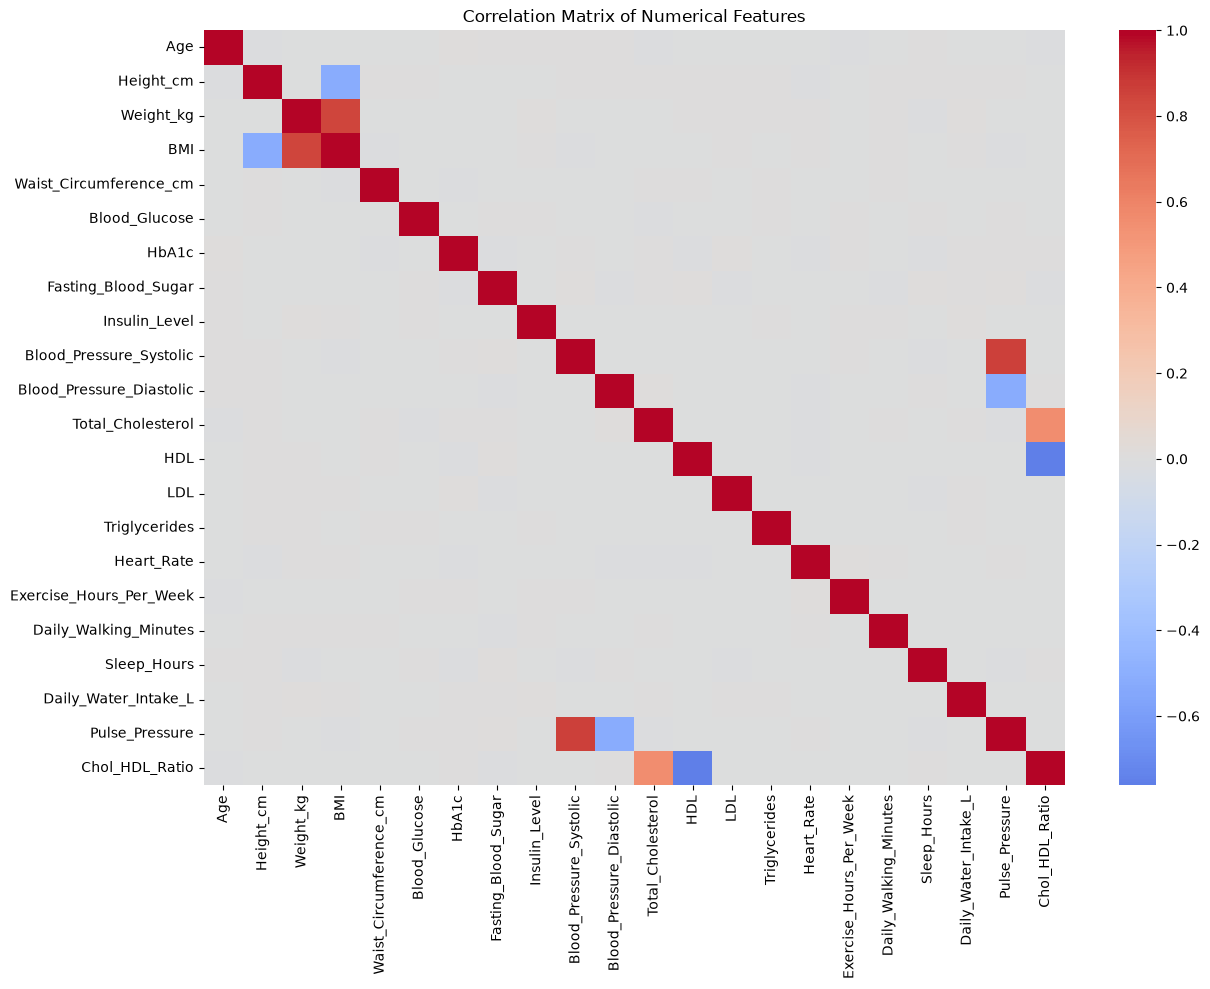

In [39]:
numeric_df = df_model.select_dtypes(include=np.number)

plt.figure(figsize=(13, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_correlation_matrix.png", dpi=180)
plt.show()


# 8. Outlier Analysis

The boxplots above provide the outlier inspection for important numerical variables.

Extreme values are not automatically deleted because they may represent real patient variation. The modeling pipeline handles missing values and scaling consistently instead of applying arbitrary row removal.


# 9. Prepare the Modeling Table

The final raw feature set retains clinically meaningful measurements and the two engineered variables.

The final model representation will be reduced again after encoding with a **training-only mutual-information selector**.


In [40]:
FINAL_FEATURES = [
    "Age",
    "BMI",
    "Waist_Circumference_cm",
    "Blood_Glucose",
    "HbA1c",
    "Fasting_Blood_Sugar",
    "Insulin_Level",
    "Blood_Pressure_Systolic",
    "Blood_Pressure_Diastolic",
    "Total_Cholesterol",
    "HDL",
    "Family_History_Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Diet_Quality",
    "Physical_Activity_Level",
    "Pulse_Pressure",
    "Chol_HDL_Ratio",
]

FINAL_FEATURES = [c for c in FINAL_FEATURES if c in df_model.columns]

print("Final raw feature count:", len(FINAL_FEATURES))
display(pd.DataFrame({"Selected feature": FINAL_FEATURES}))


Final raw feature count: 18


,Selected feature
0,Age
1,BMI
2,Waist_Circumference_cm
3,Blood_Glucose
4,HbA1c
5,Fasting_Blood_Sugar
6,Insulin_Level
7,Blood_Pressure_Systolic
8,Blood_Pressure_Diastolic
9,Total_Cholesterol


# 10. Train / Validation / Test Split

We use:

- **70% training**
- **15% validation**
- **15% test**

The split is stratified so all three classes remain represented. The test set stays untouched until final evaluation.


In [41]:
X_all = df_model[FINAL_FEATURES].copy()
y_all = df["Diabetes_Risk"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (35000, 18) (35000,)
Validation: (7500, 18) (7500,)
Test: (7500, 18) (7500,)


### Target Association for Raw Features

Mutual information is calculated using the **training data only**. This provides a non-linear association signal without leaking validation or test information.


,feature,mutual_information
0,Fasting_Blood_Sugar,0.094773
1,HbA1c,0.061478
2,Age,0.025536
3,Family_History_Diabetes,0.025391
4,BMI,0.017743
5,Hypertension,0.009649
6,Blood_Pressure_Systolic,0.009618
7,Physical_Activity_Level,0.007875
8,Diet_Quality,0.007297
9,Heart_Disease,0.006963


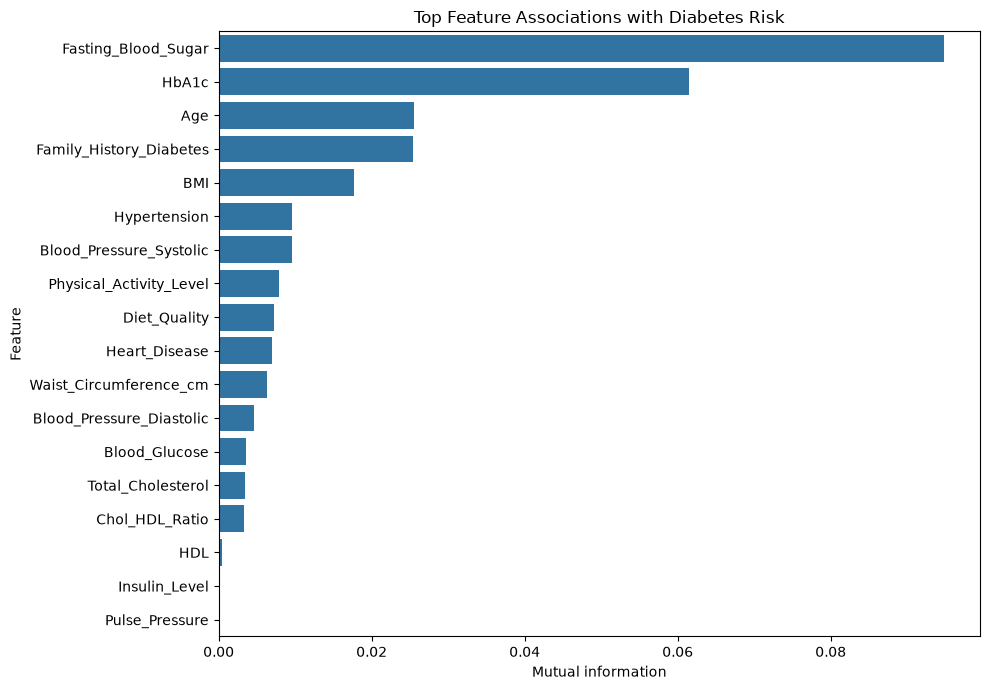

In [42]:
# Prepare a training-only representation for mutual information.
mi_frame = X_train_fe.copy()

num_cols_mi = mi_frame.select_dtypes(include=np.number).columns.tolist()
cat_cols_mi = [c for c in mi_frame.columns if c not in num_cols_mi]

num_values = SimpleImputer(strategy="median").fit_transform(mi_frame[num_cols_mi])

if cat_cols_mi:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    cat_values = cat_imputer.fit_transform(mi_frame[cat_cols_mi])

    # Stable integer codes for MI's discrete features.
    encoded_cats = np.zeros_like(cat_values, dtype=float)
    for j, col in enumerate(cat_cols_mi):
        categories = pd.Series(cat_values[:, j]).astype(str).astype("category")
        encoded_cats[:, j] = categories.cat.codes
else:
    encoded_cats = np.empty((len(mi_frame), 0))

mi_X = np.hstack([num_values, encoded_cats])
mi_discrete = np.array([False] * len(num_cols_mi) + [True] * len(cat_cols_mi))

mi_scores = mutual_info_classif(
    mi_X,
    y_train.map({"Low": 0, "Moderate": 1, "High": 2}),
    discrete_features=mi_discrete,
    random_state=SEED,
)

mi_table = (
    pd.DataFrame({
        "feature": num_cols_mi + cat_cols_mi,
        "mutual_information": mi_scores
    })
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

display(mi_table)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=mi_table.head(20),
    y="feature",
    x="mutual_information",
    orient="h"
)
plt.title("Top Feature Associations with Diabetes Risk")
plt.xlabel("Mutual information")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_feature_mi_ranking.png", dpi=180)
plt.show()

# 11. Leakage-Safe Preprocessing

Numerical features are:

**median imputation → standardization**

Categorical features are:

**mode imputation → one-hot encoding**

All preprocessing parameters are learned from training data only.

After encoding, a second training-only mutual-information selector reduces the final numerical representation.


In [43]:
Xtr = X_train_fe[FINAL_FEATURES].copy()
Xva = X_val_fe[FINAL_FEATURES].copy()
Xte = X_test_fe[FINAL_FEATURES].copy()

numeric_features = Xtr.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in Xtr.columns if c not in numeric_features]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

Xtr_pre = preprocessor.fit_transform(Xtr)
Xva_pre = preprocessor.transform(Xva)
Xte_pre = preprocessor.transform(Xte)

feature_names_pre = preprocessor.get_feature_names_out()

print("Numeric raw features:", len(numeric_features))
print("Categorical raw features:", len(categorical_features))
print("Encoded feature matrix:", Xtr_pre.shape)
print("Validation matrix:", Xva_pre.shape)
print("Test matrix:", Xte_pre.shape)

Numeric raw features: 13
Categorical raw features: 5
Encoded feature matrix: (35000, 25)
Validation matrix: (7500, 25)
Test matrix: (7500, 25)


### Final Encoded Feature Selection


In [44]:
selector = SelectPercentile(
    score_func=mutual_info_classif,
    percentile=70
)

y_train_num = y_train.map({"Low": 0, "Moderate": 1, "High": 2}).values
y_val_num = y_val.map({"Low": 0, "Moderate": 1, "High": 2}).values
y_test_num = y_test.map({"Low": 0, "Moderate": 1, "High": 2}).values

Xtr_sel = selector.fit_transform(Xtr_pre, y_train_num)
Xva_sel = selector.transform(Xva_pre)
Xte_sel = selector.transform(Xte_pre)

selected_transformed_names = feature_names_pre[selector.get_support()]

print("Before encoded selection:", Xtr_pre.shape[1])
print("After encoded selection:", Xtr_sel.shape[1])
print("\nSelected encoded features:")
display(pd.DataFrame({"feature": selected_transformed_names}))

Before encoded selection: 25
After encoded selection: 17

Selected encoded features:


,feature
0,num__Age
1,num__BMI
2,num__Blood_Glucose
3,num__HbA1c
4,num__Fasting_Blood_Sugar
5,num__Blood_Pressure_Systolic
6,num__Blood_Pressure_Diastolic
7,num__Pulse_Pressure
8,cat__Family_History_Diabetes_No
9,cat__Family_History_Diabetes_Yes


### Representation Summary

For one patient:

$$
x \in \mathbb{R}^{d}
$$

For the dataset:

$$
X \in \mathbb{R}^{N \times d}
$$

where each row is one patient and each column is one selected model feature.


In [45]:
representation_summary = pd.DataFrame({
    "Stage": [
        "Raw dataframe",
        "Candidate feature dataframe",
        "After feature engineering",
        "Encoded feature matrix",
        "Final selected model input",
    ],
    "Shape": [
        str(df.shape),
        str(X_all.shape),
        str(Xtr.shape),
        str(Xtr_pre.shape),
        str(Xtr_sel.shape),
    ],
})

display(representation_summary)

print("Final model input dimension d =", Xtr_sel.shape[1])

,Stage,Shape
0,Raw dataframe,"(50000, 41)"
1,Candidate feature dataframe,"(50000, 18)"
2,After feature engineering,"(35000, 18)"
3,Encoded feature matrix,"(35000, 25)"
4,Final selected model input,"(35000, 17)"


Final model input dimension d = 17


# 12. Model 1 - Logistic Regression

Logistic Regression provides a linear probabilistic baseline for the three-class problem.


In [46]:
model_lr = LogisticRegression(
    max_iter=1500,
    class_weight="balanced",
    random_state=SEED,
)
print(model_lr)


LogisticRegression(class_weight='balanced', max_iter=1500, random_state=42)


# 13. Model 2 - Random Forest Classifier

Random Forest combines multiple decision trees and can model non-linear feature relationships.


In [47]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)
print(model_rf)


RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=2,
                       n_estimators=200, n_jobs=-1, random_state=42)


# 14. Model 3 - HistGradientBoosting Classifier

HistGradientBoosting builds an ensemble sequentially and is suitable for non-linear tabular data.


In [48]:
model_hgb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=SEED,
)
print(model_hgb)


HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.08,
                               max_iter=250, random_state=42)


In [49]:
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "HistGradientBoosting": model_hgb,
}

model_hyperparameters = {
    name: model.get_params() for name, model in models.items()
}


# 15. Evaluate the Three Traditional ML Models

All three models use a common evaluation procedure:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Multiclass ROC-AUC
- Training time

**Macro F1** is the primary selection metric because the target is imbalanced.


In [50]:
CLASS_ORDER = ["Low", "Moderate", "High"]

def evaluate_classifier(model, X, y_true, model_name):
    start = time.perf_counter()
    model.fit(X, y_true)
    train_time = time.perf_counter() - start

    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
    else:
        y_prob = None

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Training_Time_sec": train_time,
    }

    if y_prob is not None:
        y_bin = label_binarize(y_true, classes=CLASS_ORDER)
        metrics["ROC_AUC_OVR_macro"] = roc_auc_score(
            y_bin, y_prob, multi_class="ovr", average="macro"
        )

    return metrics, y_pred, y_prob

### Validation Experiment

The three ML candidates are trained on the training representation and evaluated on the validation set. The test set remains untouched.


In [51]:
validation_results = []
validation_predictions = {}
validation_probabilities = {}

for name, prototype in models.items():
    model = clone(prototype)

    # HistGradientBoosting has no class_weight parameter, so use sample weights.
    if name == "HistGradientBoosting":
        class_counts = np.bincount(y_train_num)
        sample_weights = np.array([
            len(y_train_num) / (len(class_counts) * class_counts[v])
            for v in y_train_num
        ])
        start = time.perf_counter()
        model.fit(Xtr_sel, y_train_num, sample_weight=sample_weights)
        train_time = time.perf_counter() - start
        pred = model.predict(Xva_sel)
        prob = model.predict_proba(Xva_sel)
    else:
        start = time.perf_counter()
        model.fit(Xtr_sel, y_train_num)
        train_time = time.perf_counter() - start
        pred = model.predict(Xva_sel)
        prob = model.predict_proba(Xva_sel)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_val_num, pred),
        "Precision_macro": precision_score(y_val_num, pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_val_num, pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_val_num, pred, average="macro", zero_division=0),
        "ROC_AUC_OVR_macro": roc_auc_score(
            label_binarize(y_val_num, classes=[0,1,2]),
            prob,
            multi_class="ovr",
            average="macro",
        ),
        "Training_Time_sec": train_time,
    }

    validation_results.append(metrics)
    validation_predictions[name] = pred
    validation_probabilities[name] = prob

validation_df = pd.DataFrame(validation_results).sort_values("F1_macro", ascending=False)
display(validation_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_OVR_macro,Training_Time_sec
2,HistGradientBoosting,0.861867,0.669301,0.807664,0.716258,0.958043,1.526473
1,Random Forest,0.884667,0.832538,0.646380,0.685764,0.959431,1.958871
0,Logistic Regression,0.794133,0.568186,0.794906,0.605775,0.918618,0.216640


# 16. Traditional ML Visualization

The validation results are visualized with the same metrics used for model selection.


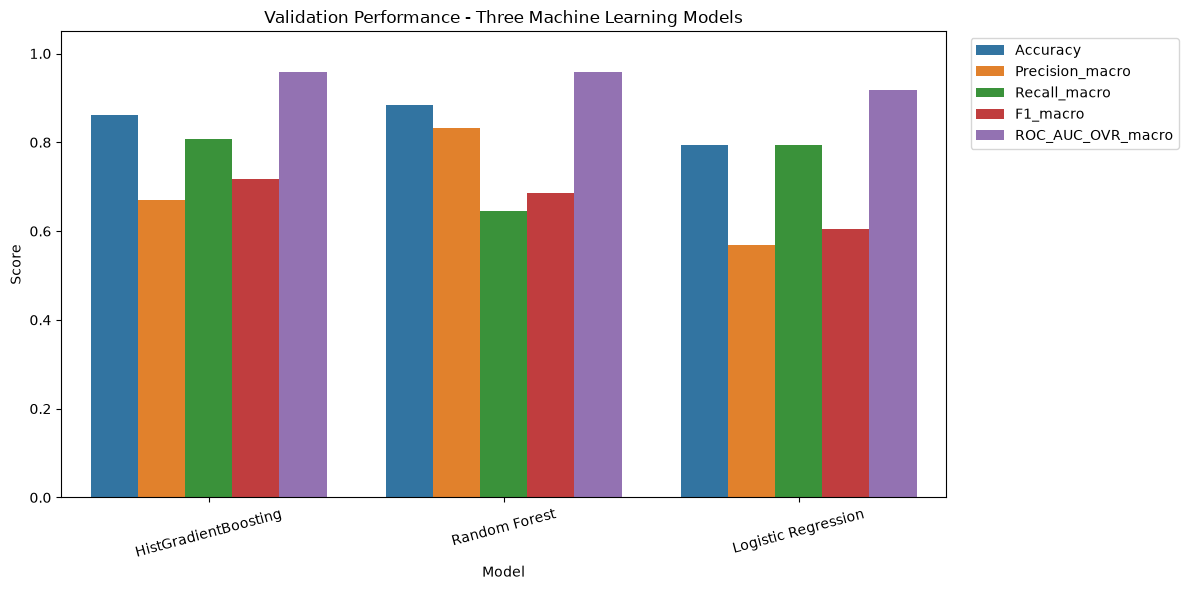

Selected best ML model by validation Macro F1: HistGradientBoosting


In [52]:
plot_metrics = ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "ROC_AUC_OVR_macro"]

plt.figure(figsize=(12, 6))
validation_melt = validation_df.melt(
    id_vars="Model",
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=validation_melt, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Validation Performance - Three Machine Learning Models")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_validation_ml_comparison.png", dpi=180)
plt.show()

best_ml_name = validation_df.iloc[0]["Model"]
print("Selected best ML model by validation Macro F1:", best_ml_name)

### Best ML Validation Check


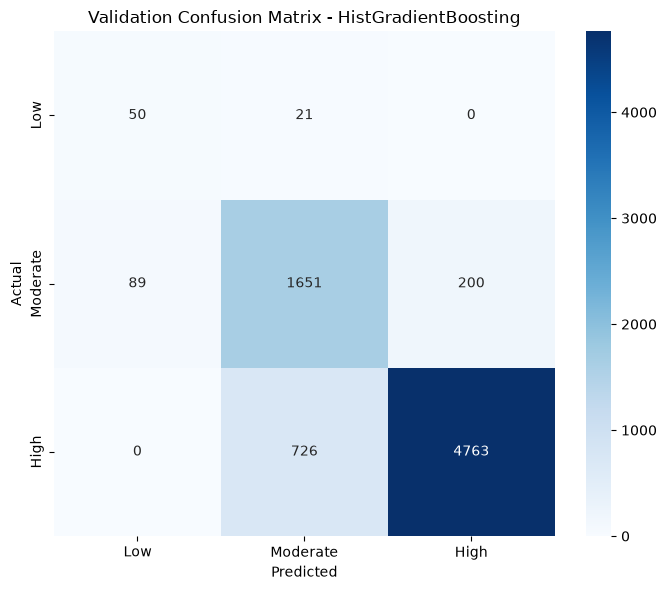

              precision    recall  f1-score   support

         Low     0.3597    0.7042    0.4762        71
    Moderate     0.6885    0.8510    0.7612      1940
        High     0.9597    0.8677    0.9114      5489

    accuracy                         0.8619      7500
   macro avg     0.6693    0.8077    0.7163      7500
weighted avg     0.8839    0.8619    0.8684      7500



In [53]:
best_val_pred = validation_predictions[best_ml_name]

cm = confusion_matrix(y_val_num, best_val_pred, labels=[0,1,2])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Validation Confusion Matrix - {best_ml_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_validation_best_ml_confusion_matrix.png", dpi=180)
plt.show()

print(classification_report(
    y_val_num,
    best_val_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
))

### Final ML Training on Train + Validation

After selecting the best candidate by validation Macro F1, all three models are refit on train + validation for final test comparison.


In [54]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

X_trainval_fe = add_engineered_features(X_trainval)
X_test_final_fe = add_engineered_features(X_test)

Xtrv = X_trainval_fe[FINAL_FEATURES].copy()
Xtf = X_test_final_fe[FINAL_FEATURES].copy()

numeric_features_final = Xtrv.select_dtypes(include=np.number).columns.tolist()
categorical_features_final = [c for c in Xtrv.columns if c not in numeric_features_final]

try:
    onehot_final = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_final = OneHotEncoder(handle_unknown="ignore", sparse=False)

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features_final,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot_final),
            ]),
            categorical_features_final,
        ),
    ]
)

Xtrv_pre = final_preprocessor.fit_transform(Xtrv)
Xtf_pre = final_preprocessor.transform(Xtf)

final_feature_names_pre = final_preprocessor.get_feature_names_out()

y_trainval_num = y_trainval.map({"Low": 0, "Moderate": 1, "High": 2}).values

final_selector = SelectPercentile(
    score_func=mutual_info_classif,
    percentile=70
)

Xtrv_sel = final_selector.fit_transform(Xtrv_pre, y_trainval_num)
Xtf_sel = final_selector.transform(Xtf_pre)

print("Final train+validation matrix:", Xtrv_sel.shape)
print("Final test matrix:", Xtf_sel.shape)

Final train+validation matrix: (42500, 17)
Final test matrix: (7500, 17)


### Final Test Evaluation - Three ML Models


In [55]:
final_ml_results = []
final_ml_artifacts = {}

for name, prototype in models.items():
    model = clone(prototype)

    if name == "HistGradientBoosting":
        class_counts = np.bincount(y_trainval_num)
        sample_weights_final = np.array([
            len(y_trainval_num) / (len(class_counts) * class_counts[v])
            for v in y_trainval_num
        ])

        start = time.perf_counter()
        model.fit(Xtrv_sel, y_trainval_num, sample_weight=sample_weights_final)
        train_time = time.perf_counter() - start
    else:
        start = time.perf_counter()
        model.fit(Xtrv_sel, y_trainval_num)
        train_time = time.perf_counter() - start

    pred = model.predict(Xtf_sel)
    prob = model.predict_proba(Xtf_sel)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_num, pred),
        "Precision_macro": precision_score(y_test_num, pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test_num, pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test_num, pred, average="macro", zero_division=0),
        "ROC_AUC_OVR_macro": roc_auc_score(
            label_binarize(y_test_num, classes=[0,1,2]),
            prob,
            multi_class="ovr",
            average="macro",
        ),
        "Training_Time_sec": train_time,
    }

    final_ml_results.append(result)
    final_ml_artifacts[name] = {
        "model": model,
        "prediction": pred,
        "probability": prob,
    }

final_ml_df = pd.DataFrame(final_ml_results).sort_values("F1_macro", ascending=False)
display(final_ml_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_OVR_macro,Training_Time_sec
2,HistGradientBoosting,0.864000,0.675501,0.827056,0.725863,0.963001,1.515570
1,Random Forest,0.882133,0.806242,0.645276,0.682374,0.964183,2.085196
0,Logistic Regression,0.782000,0.557440,0.782949,0.593294,0.913347,0.198453


### ML Test Comparison Visualization


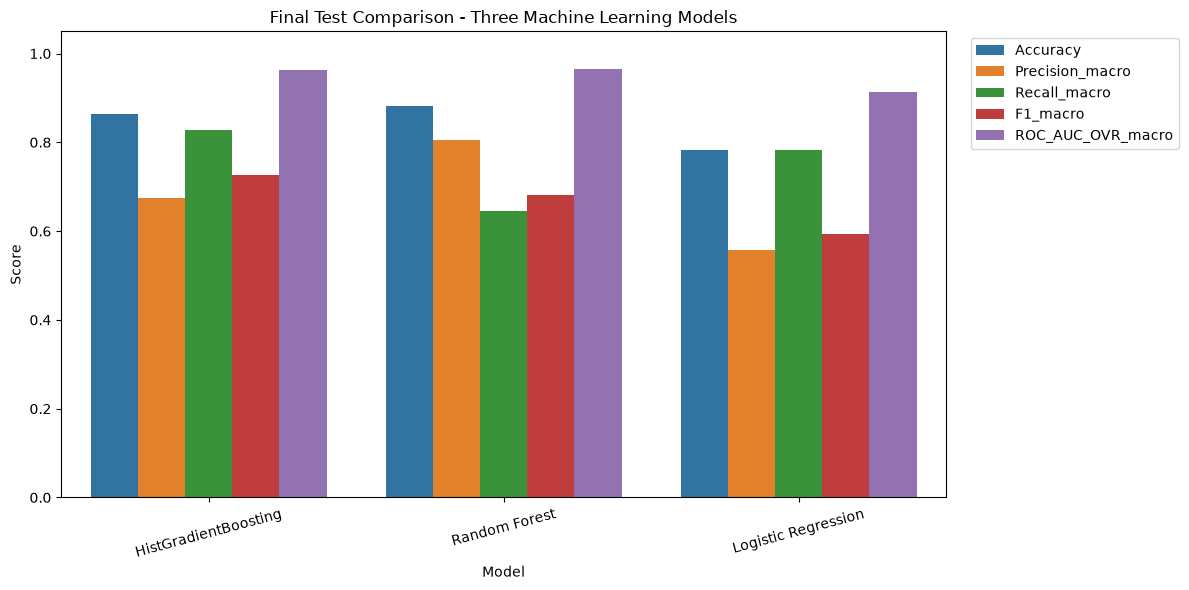

Best ML model on final test: HistGradientBoosting


In [56]:
test_ml_melt = final_ml_df.melt(
    id_vars="Model",
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=test_ml_melt, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Final Test Comparison - Three Machine Learning Models")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_final_ml_comparison.png", dpi=180)
plt.show()

best_ml_name_final = final_ml_df.iloc[0]["Model"]
best_ml_artifact = final_ml_artifacts[best_ml_name_final]

print("Best ML model on final test:", best_ml_name_final)

### Best ML Model - Detailed Test Evaluation


,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_OVR_macro
HistGradientBoosting,0.864,0.675501,0.827056,0.725863,0.963001


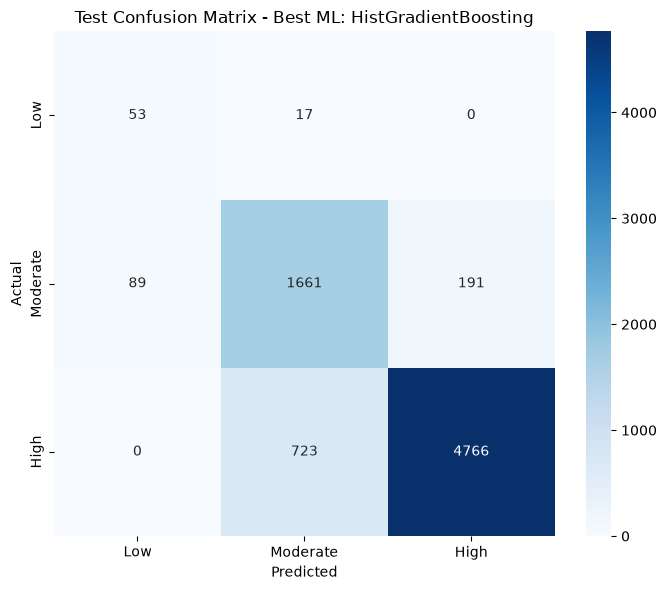

              precision    recall  f1-score   support

         Low     0.3732    0.7571    0.5000        70
    Moderate     0.6918    0.8557    0.7651      1941
        High     0.9615    0.8683    0.9125      5489

    accuracy                         0.8640      7500
   macro avg     0.6755    0.8271    0.7259      7500
weighted avg     0.8862    0.8640    0.8705      7500



In [57]:
best_ml_pred = best_ml_artifact["prediction"]
best_ml_prob = best_ml_artifact["probability"]

best_ml_metrics = {
    "Accuracy": accuracy_score(y_test_num, best_ml_pred),
    "Precision_macro": precision_score(y_test_num, best_ml_pred, average="macro", zero_division=0),
    "Recall_macro": recall_score(y_test_num, best_ml_pred, average="macro", zero_division=0),
    "F1_macro": f1_score(y_test_num, best_ml_pred, average="macro", zero_division=0),
    "ROC_AUC_OVR_macro": roc_auc_score(
        label_binarize(y_test_num, classes=[0,1,2]),
        best_ml_prob,
        multi_class="ovr",
        average="macro",
    ),
}

display(pd.DataFrame([best_ml_metrics], index=[best_ml_name_final]))

cm_ml = confusion_matrix(y_test_num, best_ml_pred, labels=[0,1,2])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_ml,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Test Confusion Matrix - Best ML: {best_ml_name_final}")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_best_ml_confusion_matrix.png", dpi=180)
plt.show()

print(classification_report(
    y_test_num,
    best_ml_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
))

### Best ML Probability / ROC Visualization

The selected ML model outputs a probability for each risk class. One-vs-rest ROC curves visualize class discrimination.


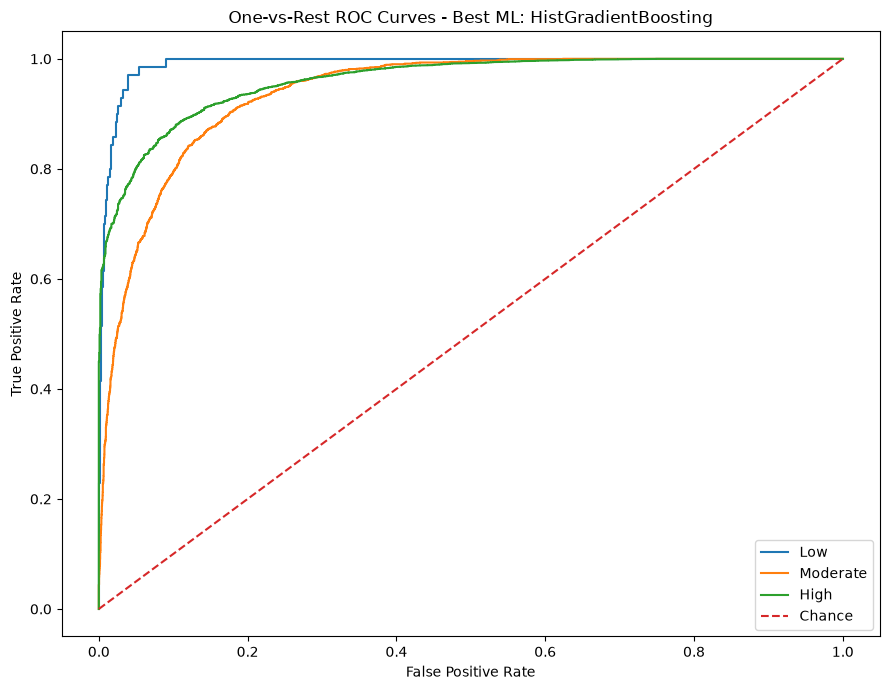

In [58]:
y_test_bin = label_binarize(y_test_num, classes=[0,1,2])

plt.figure(figsize=(9, 7))

for i, cls in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_ml_prob[:, i])
    plt.plot(fpr, tpr, label=cls)

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves - Best ML: {best_ml_name_final}")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_best_ml_roc_curves.png", dpi=180)
plt.show()

# 17. Deep Learning from Scratch - Concept

The Deep Learning model is implemented directly with **NumPy only**.

The workflow follows the same step-by-step structure as the HousePrice notebook:

```text
Prepare Data
    ↓
Step 1 - Activations
    ↓
Step 2 - Initialize Network
    ↓
Step 3 - Forward Propagation
    ↓
Step 4 - Cross-Entropy Loss
    ↓
Step 5 - Backpropagation
    ↓
Step 6 - Gradient Descent
    ↓
Step 7 - Training
    ↓
Step 8 - Prediction
    ↓
Step 9 - Evaluation
```

Because this is a three-class classification problem, the output layer produces one probability for each class: `Low`, `Moderate`, and `High`.


# 18. Deep Learning Mathematics

For the first hidden layer:

```text
Z1 = XW1 + b1
H1 = ReLU(Z1)
```

For the second hidden layer:

```text
Z2 = H1W2 + b2
H2 = ReLU(Z2)
```

For the output layer:

```text
Z3 = H2W3 + b3
y_hat = Softmax(Z3)
```

The network is trained with multi-class cross-entropy:

```text
Loss = -(1/N) * sum(log(P(correct class)))
```

The complete learning cycle is:

```text
Forward -> Loss -> Backpropagation -> Gradient Descent
```


# 19. Prepare the Data for the NumPy Neural Network

The neural network receives the final leakage-safe, preprocessed, and feature-selected numerical matrix.

```text
Raw patient data
    -> feature engineering
    -> preprocessing
    -> feature selection
    -> NumPy matrix
    -> neural network
```

The target is already encoded as integers:

```text
0 = Low
1 = Moderate
2 = High
```


In [59]:
X_train_dl = np.asarray(Xtr_sel, dtype=np.float64)
X_val_dl = np.asarray(Xva_sel, dtype=np.float64)
X_test_dl = np.asarray(Xtf_sel, dtype=np.float64)

# Convert labels to integer class IDs
y_train_dl = np.asarray(y_train_num, dtype=np.int64)
y_val_dl = np.asarray(y_val_num, dtype=np.int64)
y_test_dl = np.asarray(y_test_num, dtype=np.int64)

print("Deep Learning input data:")
print("X_train:", X_train_dl.shape)
print("X_val  :", X_val_dl.shape)
print("X_test :", X_test_dl.shape)
print("Classes:", CLASS_ORDER)

Deep Learning input data:
X_train: (35000, 17)
X_val  : (7500, 17)
X_test : (7500, 17)
Classes: ['Low', 'Moderate', 'High']


# 20. Step 1 - Implement Activation Functions

The hidden layers use **ReLU** because it introduces nonlinearity.

The output layer uses **Softmax** because this is a multi-class classification problem. Softmax converts the three output logits into probabilities whose sum is approximately 1.

The derivatives are required during backpropagation.


In [60]:
def relu(x):
    return np.maximum(0.0, x)


def relu_derivative(x):
    return (x > 0).astype(np.float64)


def softmax(x):
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# 21. Step 2 - Initialize the Network

The architecture is:

```text
d -> 64 -> 32 -> 3
```

where `d` is the final selected feature dimension.

Weights use He-style initialization for the ReLU layers, and biases start at zero.

The NumPy class below contains the learnable parameters and the forward/backward/update operations used in the following steps.


In [61]:
class NumpyDiabetesMLP:
    def __init__(self, input_dim, hidden1=64, hidden2=32, output_dim=3, seed=42):
        rng = np.random.default_rng(seed)

        self.input_dim = input_dim
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.output_dim = output_dim

        # He initialization for ReLU hidden layers.
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim), size=(input_dim, hidden1))
        self.b1 = np.zeros((1, hidden1))

        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden1), size=(hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))

        self.W3 = rng.normal(0, np.sqrt(2.0 / hidden2), size=(hidden2, output_dim))
        self.b3 = np.zeros((1, output_dim))

    @staticmethod
    def relu(x):
        return np.maximum(0, x)

    @staticmethod
    def relu_derivative(x):
        return (x > 0).astype(float)

    @staticmethod
    def softmax(x):
        shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(shifted)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h1 = self.relu(z1)

        z2 = h1 @ self.W2 + self.b2
        h2 = self.relu(z2)

        z3 = h2 @ self.W3 + self.b3
        y_prob = self.softmax(z3)

        cache = {
            "X": X,
            "z1": z1,
            "h1": h1,
            "z2": z2,
            "h2": h2,
            "z3": z3,
            "y_prob": y_prob,
        }
        return y_prob, cache

    @staticmethod
    def cross_entropy(y_true, y_prob):
        eps = 1e-8
        clipped = np.clip(y_prob, eps, 1.0 - eps)
        n = len(y_true)
        return -np.mean(np.log(clipped[np.arange(n), y_true]))

    def backward(self, y_true, cache):
        X = cache["X"]
        z1 = cache["z1"]
        h1 = cache["h1"]
        z2 = cache["z2"]
        h2 = cache["h2"]
        y_prob = cache["y_prob"]

        n = len(X)

        # Softmax + cross-entropy gradient.
        dz3 = y_prob.copy()
        dz3[np.arange(n), y_true] -= 1
        dz3 /= n

        dW3 = h2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        dh2 = dz3 @ self.W3.T
        dz2 = dh2 * self.relu_derivative(z2)

        dW2 = h1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dh1 = dz2 @ self.W2.T
        dz1 = dh1 * self.relu_derivative(z1)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        return {
            "dW1": dW1, "db1": db1,
            "dW2": dW2, "db2": db2,
            "dW3": dW3, "db3": db3,
        }

    def update(self, gradients, learning_rate):
        self.W1 -= learning_rate * gradients["dW1"]
        self.b1 -= learning_rate * gradients["db1"]

        self.W2 -= learning_rate * gradients["dW2"]
        self.b2 -= learning_rate * gradients["db2"]

        self.W3 -= learning_rate * gradients["dW3"]
        self.b3 -= learning_rate * gradients["db3"]

    def predict_proba(self, X):
        prob, _ = self.forward(X)
        return prob

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def save_weights(self, path):
        np.savez(
            path,
            W1=self.W1, b1=self.b1,
            W2=self.W2, b2=self.b2,
            W3=self.W3, b3=self.b3,
        )

# 22. Step 3 - Forward Propagation

The forward pass applies each layer in order:

```text
Z1 = X @ W1 + b1
H1 = ReLU(Z1)

Z2 = H1 @ W2 + b2
H2 = ReLU(Z2)

Z3 = H2 @ W3 + b3
P  = Softmax(Z3)
```

The intermediate values are stored in `cache` because backpropagation needs them later.


In [62]:
# Small forward-pass check
demo_model = NumpyDiabetesMLP(
    input_dim=X_train_dl.shape[1],
    hidden1=64,
    hidden2=32,
    output_dim=3,
    seed=SEED,
)

demo_prob, demo_cache = demo_model.forward(X_train_dl[:3])

print("Input shape:", X_train_dl[:3].shape)
print("Output probability shape:", demo_prob.shape)
print("Probability sums:", demo_prob.sum(axis=1))


Input shape: (3, 17)
Output probability shape: (3, 3)
Probability sums: [1. 1. 1.]


# 23. Step 4 - Cross-Entropy Loss

For a patient with true class `y`, the loss uses the probability assigned to that correct class:

```text
Loss = -log(P(correct class))
```

The batch loss is the mean of the individual losses. A lower loss means the network is assigning higher probability to the correct classes.


In [63]:
demo_loss = demo_model.cross_entropy(y_train_dl[:3], demo_prob)
print("Example cross-entropy loss:", round(float(demo_loss), 6))


Example cross-entropy loss: 0.842627


# 36. Step 5 - Backpropagation

Backpropagation applies the chain rule from the output layer back to the input.

For Softmax + cross-entropy, the output gradient simplifies to:

```text
dZ3 = (P - Y) / N
```

The gradients are then propagated through both ReLU hidden layers to obtain gradients for all weight matrices and biases.


In [64]:
demo_gradients = demo_model.backward(
    y_train_dl[:3],
    demo_cache,
)

for name, value in demo_gradients.items():
    print(f"{name}: {value.shape}")


dW1: (17, 64)
db1: (1, 64)
dW2: (64, 32)
db2: (1, 32)
dW3: (32, 3)
db3: (1, 3)


# 37. Step 6 - Gradient Descent

The network updates each parameter using:

```text
W = W - learning_rate * dW
b = b - learning_rate * db
```

One update moves the parameters in the direction that reduces the loss. Repeating this update across epochs allows the network to learn.


In [65]:
demo_model.update(demo_gradients, learning_rate=0.01)
print("One gradient-descent update completed.")


One gradient-descent update completed.


# 38. Step 7 - Training Loop

The training loop repeats the complete learning cycle:

```text
Forward
   ->
Cross-Entropy Loss
   ->
Backpropagation
   ->
Gradient Descent
   ->
Repeat for each epoch
```

The validation loss is recorded after every epoch so that we can monitor generalization and detect divergence between training and validation behavior.


In [66]:
DL_INPUT_DIM = X_train_dl.shape[1]
DL_HIDDEN_1 = 64
DL_HIDDEN_2 = 32
DL_OUTPUT_DIM = 3

print("Deep Learning architecture:")
print(f"{DL_INPUT_DIM} -> {DL_HIDDEN_1} -> {DL_HIDDEN_2} -> {DL_OUTPUT_DIM}")
print("Activations: ReLU -> ReLU -> Softmax")
print("Loss: Multi-class Cross-Entropy")

dl_model = NumpyDiabetesMLP(
    input_dim=DL_INPUT_DIM,
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

DL_LEARNING_RATE = 0.01
DL_EPOCHS = 300

train_loss_history = []
val_loss_history = []

for epoch in range(DL_EPOCHS):
    train_prob, train_cache = dl_model.forward(X_train_dl)
    train_loss = dl_model.cross_entropy(y_train_dl, train_prob)

    gradients = dl_model.backward(y_train_dl, train_cache)
    dl_model.update(gradients, DL_LEARNING_RATE)

    val_prob = dl_model.predict_proba(X_val_dl)
    val_loss = dl_model.cross_entropy(y_val_dl, val_prob)

    train_loss_history.append(float(train_loss))
    val_loss_history.append(float(val_loss))

    if epoch % 25 == 0 or epoch == DL_EPOCHS - 1:
        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss = {train_loss:.5f} | "
            f"Val Loss = {val_loss:.5f}"
        )


Deep Learning architecture:
17 -> 64 -> 32 -> 3
Activations: ReLU -> ReLU -> Softmax
Loss: Multi-class Cross-Entropy
Epoch   0 | Train Loss = 1.16031 | Val Loss = 1.10673
Epoch  25 | Train Loss = 0.63961 | Val Loss = 0.63607
Epoch  50 | Train Loss = 0.56611 | Val Loss = 0.56471
Epoch  75 | Train Loss = 0.52890 | Val Loss = 0.52777
Epoch 100 | Train Loss = 0.50353 | Val Loss = 0.50253
Epoch 125 | Train Loss = 0.48464 | Val Loss = 0.48372
Epoch 150 | Train Loss = 0.46984 | Val Loss = 0.46901
Epoch 175 | Train Loss = 0.45789 | Val Loss = 0.45715
Epoch 200 | Train Loss = 0.44803 | Val Loss = 0.44738
Epoch 225 | Train Loss = 0.43975 | Val Loss = 0.43920
Epoch 250 | Train Loss = 0.43271 | Val Loss = 0.43227
Epoch 275 | Train Loss = 0.42667 | Val Loss = 0.42634
Epoch 299 | Train Loss = 0.42163 | Val Loss = 0.42139


### Training Curve

The training and validation loss curves provide a direct view of the learning process. A generally decreasing training loss indicates that the network is fitting the training data, while the validation curve shows whether this improvement transfers to unseen validation samples.


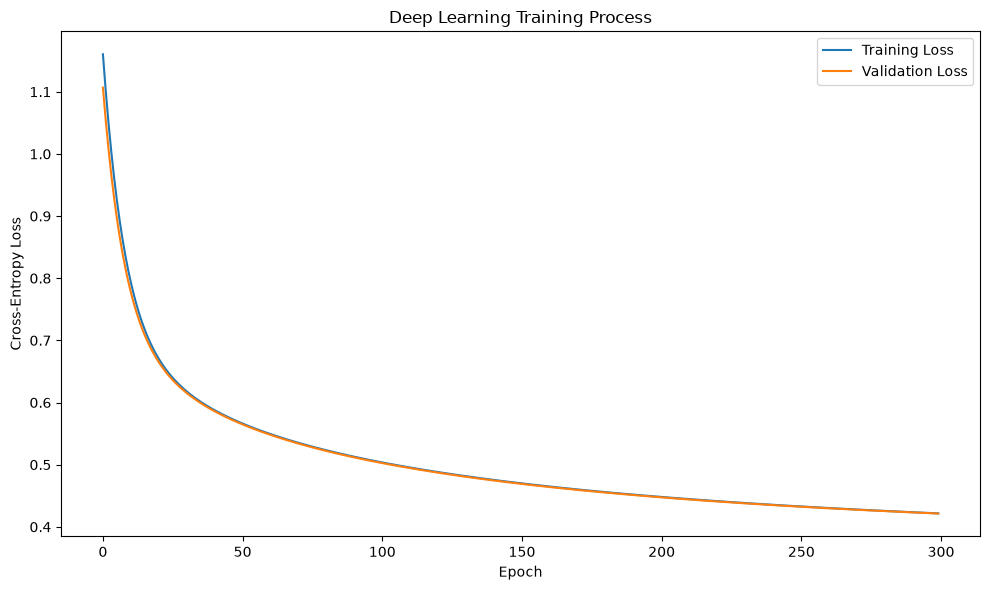

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Training Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Deep Learning Training Process")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "10_dl_loss_curve.png", dpi=180)
plt.show()


# 39. Step 8 - Deep Learning Prediction

After the training configuration is fixed, the final neural network is retrained on **train + validation** while the test set remains untouched.

For every test patient, the network returns three class probabilities:

```text
P(Low) + P(Moderate) + P(High) = 1
```

The class with the highest probability becomes the final prediction.


In [69]:
# Final training on train + validation

final_dl_model = NumpyDiabetesMLP(
    input_dim=Xtrv_sel.shape[1],
    hidden1=DL_HIDDEN_1,
    hidden2=DL_HIDDEN_2,
    output_dim=DL_OUTPUT_DIM,
    seed=SEED,
)

final_dl_train_loss = []
final_dl_epochs = DL_EPOCHS

# Convert once to NumPy
X_trainval_final = np.asarray(Xtrv_sel, dtype=np.float64)
X_test_final = np.asarray(Xtf_sel, dtype=np.float64)

for epoch in range(final_dl_epochs):

    # Forward propagation
    prob, cache = final_dl_model.forward(X_trainval_final)

    # Cross-entropy loss
    loss = final_dl_model.cross_entropy(
        y_trainval_num,
        prob
    )

    # Backpropagation
    gradients = final_dl_model.backward(
        y_trainval_num,
        cache
    )

    # Gradient descent
    final_dl_model.update(
        gradients,
        DL_LEARNING_RATE
    )

    final_dl_train_loss.append(float(loss))

    if epoch % 25 == 0 or epoch == final_dl_epochs - 1:
        print(f"Epoch {epoch:3d} | Loss = {loss:.5f}")


# Final prediction on untouched test set
final_dl_prob = final_dl_model.predict_proba(
    X_test_final
)

final_dl_pred = np.argmax(
    final_dl_prob,
    axis=1
)


# Show example probabilities
print("Example final probabilities:")

display(
    pd.DataFrame(
        final_dl_prob[:5],
        columns=[f"P({c})" for c in CLASS_ORDER]
    )
)

Epoch   0 | Loss = 1.18759
Epoch  25 | Loss = 0.70939
Epoch  50 | Loss = 0.62245
Epoch  75 | Loss = 0.57414
Epoch 100 | Loss = 0.54122
Epoch 125 | Loss = 0.51706
Epoch 150 | Loss = 0.49856
Epoch 175 | Loss = 0.48388
Epoch 200 | Loss = 0.47191
Epoch 225 | Loss = 0.46198
Epoch 250 | Loss = 0.45359
Epoch 275 | Loss = 0.44641
Epoch 299 | Loss = 0.44041
Example final probabilities:


,P(Low),P(Moderate),P(High)
0,0.016074,0.460956,0.522970
1,0.005957,0.119629,0.874414
2,0.017917,0.574714,0.407368
3,0.000284,0.014167,0.985549
4,0.004258,0.360125,0.635617


# 40. Step 9 - Deep Learning Evaluation

The final Deep Learning predictions are evaluated on the same untouched test set used by the three traditional ML models.

The main classification metrics are:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- One-vs-Rest ROC-AUC

Using the same test set and metrics makes the four-model comparison fair.


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_OVR_macro,Final_Training_Loss
0,Deep Learning - NumPy MLP,0.820133,0.518837,0.484096,0.495288,0.81663,0.440413


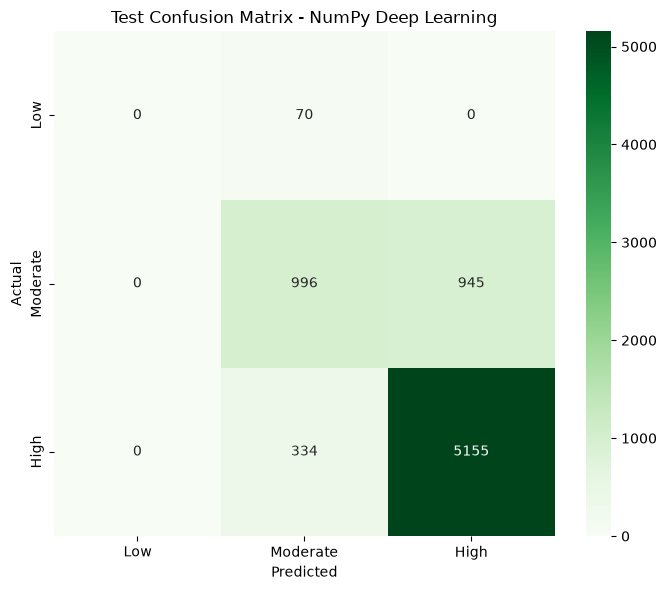

              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000        70
    Moderate     0.7114    0.5131    0.5962      1941
        High     0.8451    0.9392    0.8896      5489

    accuracy                         0.8201      7500
   macro avg     0.5188    0.4841    0.4953      7500
weighted avg     0.8026    0.8201    0.8054      7500



In [70]:
final_dl_metrics = {
    "Model": "Deep Learning - NumPy MLP",
    "Accuracy": accuracy_score(y_test_num, final_dl_pred),
    "Precision_macro": precision_score(y_test_num, final_dl_pred, average="macro", zero_division=0),
    "Recall_macro": recall_score(y_test_num, final_dl_pred, average="macro", zero_division=0),
    "F1_macro": f1_score(y_test_num, final_dl_pred, average="macro", zero_division=0),
    "ROC_AUC_OVR_macro": roc_auc_score(
        label_binarize(y_test_num, classes=[0,1,2]),
        final_dl_prob,
        multi_class="ovr",
        average="macro",
    ),
    "Final_Training_Loss": final_dl_train_loss[-1],
}

display(pd.DataFrame([final_dl_metrics]))

cm_dl = confusion_matrix(y_test_num, final_dl_pred, labels=[0,1,2])

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_dl,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix - NumPy Deep Learning")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_dl_test_confusion_matrix.png", dpi=180)
plt.show()

print(classification_report(
    y_test_num,
    final_dl_pred,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0,
))


# 41. Final Comparison - All Four Models Together

This is the central comparison:

1. Logistic Regression
2. Random Forest
3. HistGradientBoosting
4. Deep Learning - NumPy MLP

All four use the same held-out test set.


In [71]:
comparison_df = pd.concat([
    final_ml_df[[
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "ROC_AUC_OVR_macro",
        "Training_Time_sec",
    ]],
    pd.DataFrame([{
        "Model": "Deep Learning - NumPy MLP",
        "Accuracy": final_dl_metrics["Accuracy"],
        "Precision_macro": final_dl_metrics["Precision_macro"],
        "Recall_macro": final_dl_metrics["Recall_macro"],
        "F1_macro": final_dl_metrics["F1_macro"],
        "ROC_AUC_OVR_macro": final_dl_metrics["ROC_AUC_OVR_macro"],
        "Training_Time_sec": np.nan,
    }])
], ignore_index=True)

comparison_df = comparison_df.sort_values("F1_macro", ascending=False).reset_index(drop=True)
display(comparison_df)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC_OVR_macro,Training_Time_sec
0,HistGradientBoosting,0.864000,0.675501,0.827056,0.725863,0.963001,1.515570
1,Random Forest,0.882133,0.806242,0.645276,0.682374,0.964183,2.085196
2,Logistic Regression,0.782000,0.557440,0.782949,0.593294,0.913347,0.198453
3,Deep Learning - NumPy MLP,0.820133,0.518837,0.484096,0.495288,0.816630,NaN


# 42. Model Comparison Visualization

The four final models are compared using grouped metrics, Macro F1 ranking, and Accuracy versus Macro F1.


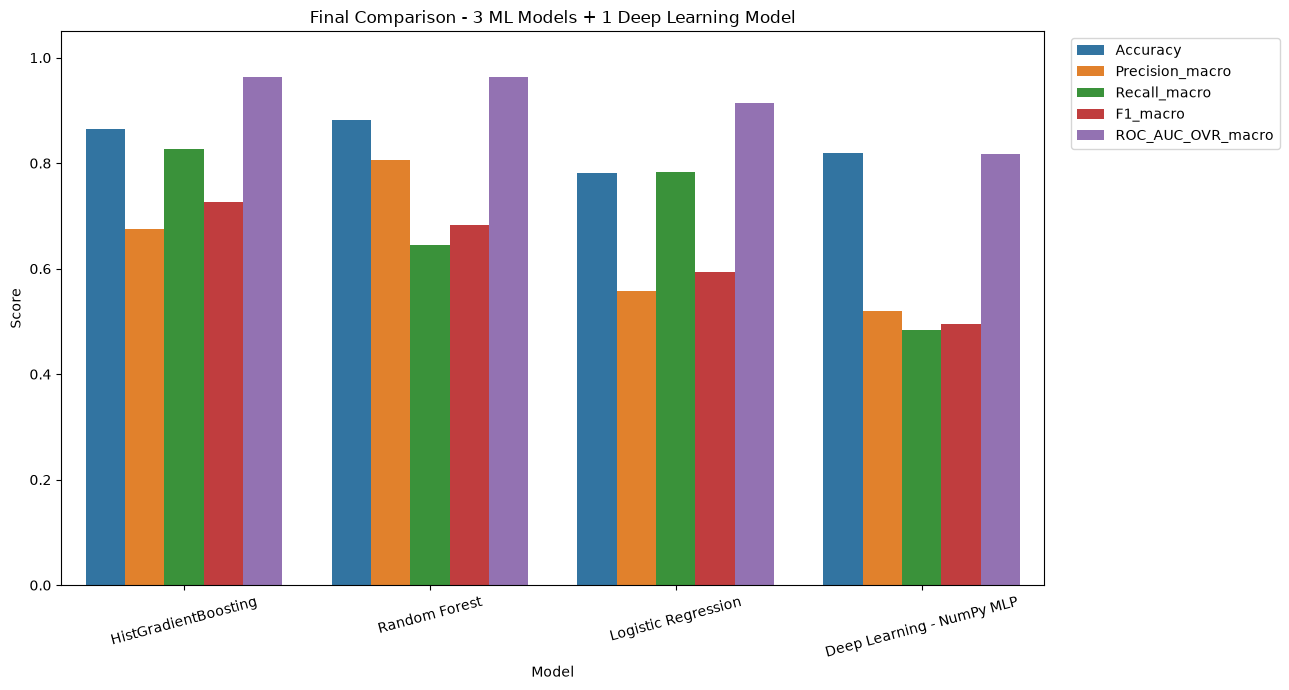

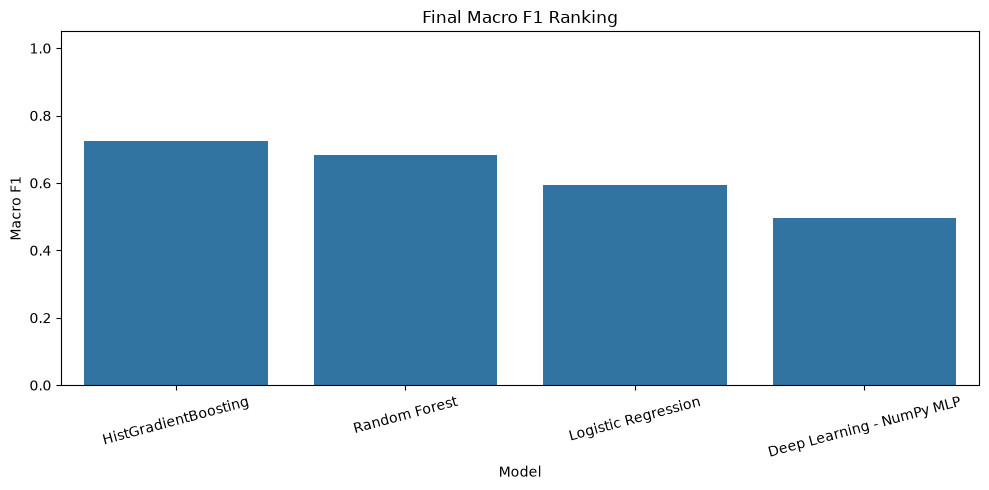

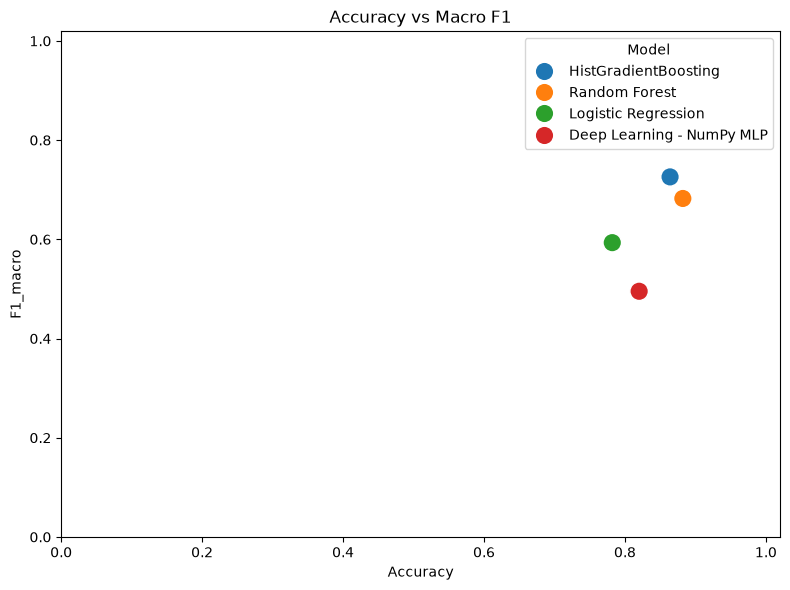

In [72]:
comparison_melt = comparison_df.melt(
    id_vars="Model",
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(13, 7))
sns.barplot(data=comparison_melt, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Final Comparison - 3 ML Models + 1 Deep Learning Model")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_four_model_comparison.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="F1_macro")
plt.ylim(0, 1.05)
plt.title("Final Macro F1 Ranking")
plt.ylabel("Macro F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_macro_f1_ranking.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=comparison_df,
    x="Accuracy",
    y="F1_macro",
    hue="Model",
    s=180,
)
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.title("Accuracy vs Macro F1")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_accuracy_vs_f1.png", dpi=180)
plt.show()

# 43. Probability Visualization for the Deployed Models

The deployed applications need both prediction and confidence information.

For classification, each selected model returns:

- predicted class;
- maximum confidence;
- full class-probability distribution.


,Actual,ML_Predicted,ML_Confidence,DL_Predicted,DL_Confidence
0,High,Moderate,0.736654,High,0.522970
1,High,High,0.918794,High,0.874414
2,High,High,0.620232,Moderate,0.574714
3,High,High,0.968950,High,0.985549
4,High,High,0.926449,High,0.635617
5,High,High,0.940356,High,0.641391
6,High,High,0.946120,High,0.858955
7,Moderate,Moderate,0.915816,Moderate,0.518816
8,Moderate,Moderate,0.857150,High,0.732841
9,Low,Low,0.885376,Moderate,0.893175


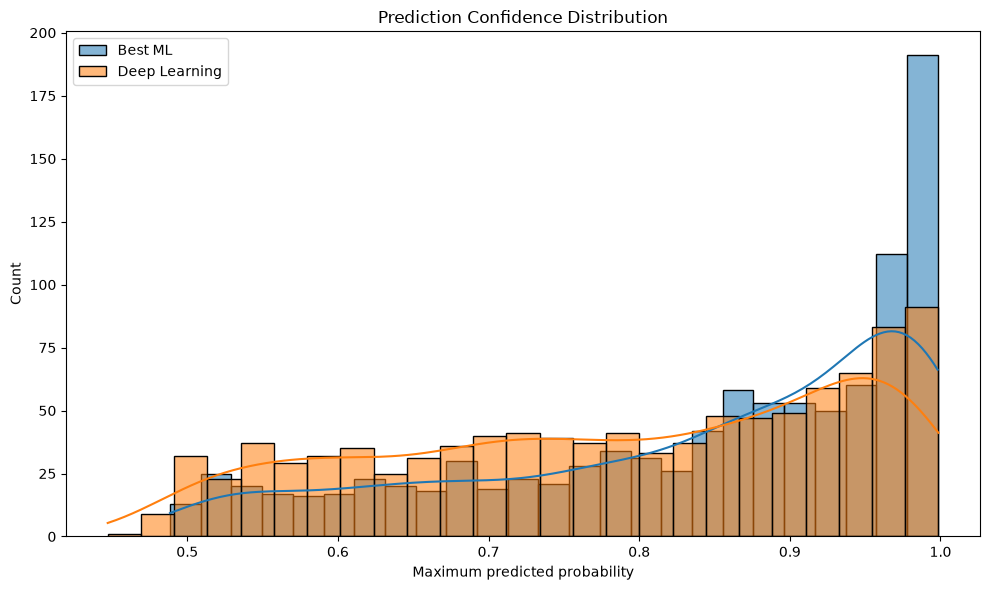

In [73]:
# Select the final DL and ML probabilities in a common structure.
sample_prob_df = pd.DataFrame({
    "Actual": [CLASS_ORDER[i] for i in y_test_num[:1000]],
    "ML_Predicted": [CLASS_ORDER[i] for i in best_ml_pred[:1000]],
    "ML_Confidence": np.max(best_ml_prob[:1000], axis=1),
    "DL_Predicted": [CLASS_ORDER[i] for i in final_dl_pred[:1000]],
    "DL_Confidence": np.max(final_dl_prob[:1000], axis=1),
})

display(sample_prob_df.head(20))

plt.figure(figsize=(10, 6))
sns.histplot(
    sample_prob_df["ML_Confidence"],
    bins=25,
    kde=True,
    label="Best ML",
    alpha=0.55,
)
sns.histplot(
    sample_prob_df["DL_Confidence"],
    bins=25,
    kde=True,
    label="Deep Learning",
    alpha=0.55,
)
plt.xlabel("Maximum predicted probability")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "16_prediction_confidence_distribution.png", dpi=180)
plt.show()

# 44. Error Analysis

The final models are compared by:

- incorrect predictions;
- model disagreements;
- prediction confidence;
- difficult minority-class cases.


In [74]:
error_analysis = X_test.copy()
error_analysis = error_analysis.reset_index(drop=True)

error_analysis["Actual"] = [CLASS_ORDER[i] for i in y_test_num]
error_analysis["ML_Prediction"] = [CLASS_ORDER[i] for i in best_ml_pred]
error_analysis["ML_Confidence"] = np.max(best_ml_prob, axis=1)
error_analysis["DL_Prediction"] = [CLASS_ORDER[i] for i in final_dl_pred]
error_analysis["DL_Confidence"] = np.max(final_dl_prob, axis=1)

error_analysis["ML_Correct"] = error_analysis["Actual"] == error_analysis["ML_Prediction"]
error_analysis["DL_Correct"] = error_analysis["Actual"] == error_analysis["DL_Prediction"]

print("Best ML errors:", (~error_analysis["ML_Correct"]).sum())
print("Deep Learning errors:", (~error_analysis["DL_Correct"]).sum())
print("Model disagreements:", (
    error_analysis["ML_Prediction"] != error_analysis["DL_Prediction"]
).sum())

display(
    error_analysis[
        (~error_analysis["ML_Correct"]) |
        (~error_analysis["DL_Correct"])
    ]
    .sort_values(["ML_Correct", "DL_Correct", "ML_Confidence"])
    .head(25)
)

Best ML errors: 1020
Deep Learning errors: 1349
Model disagreements: 1582


,Age,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,...,Physical_Activity_Level,Pulse_Pressure,Chol_HDL_Ratio,Actual,ML_Prediction,ML_Confidence,DL_Prediction,DL_Confidence,ML_Correct,DL_Correct
3980,34.0,13.9,134.0,142.5,6.8,104.9,6.2,117,65,233.1,...,Low,52,4.277064,High,Moderate,0.494074,Moderate,0.564694,False,False
2012,27.0,15.2,115.1,215.3,10.9,65.7,23.8,132,75,242.0,...,Moderate,57,2.926239,Low,Moderate,0.496384,Moderate,0.856409,False,False
7135,40.0,32.1,98.9,100.4,NaN,114.0,37.6,188,110,127.4,...,Low,78,2.091954,High,Moderate,0.496957,Moderate,0.694350,False,False
607,49.0,30.6,100.6,128.5,11.3,71.6,6.1,97,101,185.6,...,Low,-4,3.508507,High,Moderate,0.498280,Moderate,0.574105,False,False
6124,81.0,24.3,136.7,155.0,5.0,89.9,6.6,136,72,NaN,...,Moderate,64,NaN,Low,Moderate,0.499309,Moderate,0.529065,False,False
4806,68.0,27.0,116.4,118.4,5.3,183.9,39.1,112,106,290.8,...,High,6,4.460123,Moderate,High,0.499599,High,0.802850,False,False
1070,70.0,33.3,65.4,225.9,11.5,109.7,28.3,138,105,198.7,...,High,33,2.270857,Moderate,High,0.500131,High,0.936446,False,False
2203,21.0,21.4,137.0,213.9,8.7,155.3,42.9,106,71,179.2,...,High,35,4.513854,High,Moderate,0.501388,Moderate,0.530771,False,False
2971,74.0,25.5,77.2,NaN,4.9,132.8,15.3,102,109,156.8,...,Moderate,-7,1.928659,Moderate,High,0.501406,High,0.582236,False,False
5032,38.0,14.2,72.4,152.4,10.4,180.1,7.3,148,80,149.0,...,High,68,1.862500,Moderate,High,0.502461,High,0.855941,False,False


# 45. Feature Importance / Interpretation

Random Forest feature importance is shown as a complementary view of which selected representation features are influential.

Feature importance describes model contribution, not medical causality.


,feature,importance
4,num__Fasting_Blood_Sugar,0.257190
3,num__HbA1c,0.218958
0,num__Age,0.102933
1,num__BMI,0.092380
5,num__Blood_Pressure_Systolic,0.064538
6,num__Blood_Pressure_Diastolic,0.053016
2,num__Blood_Glucose,0.046915
8,cat__Family_History_Diabetes_Yes,0.032410
7,cat__Family_History_Diabetes_No,0.026397
15,cat__Diet_Quality_Poor,0.020059


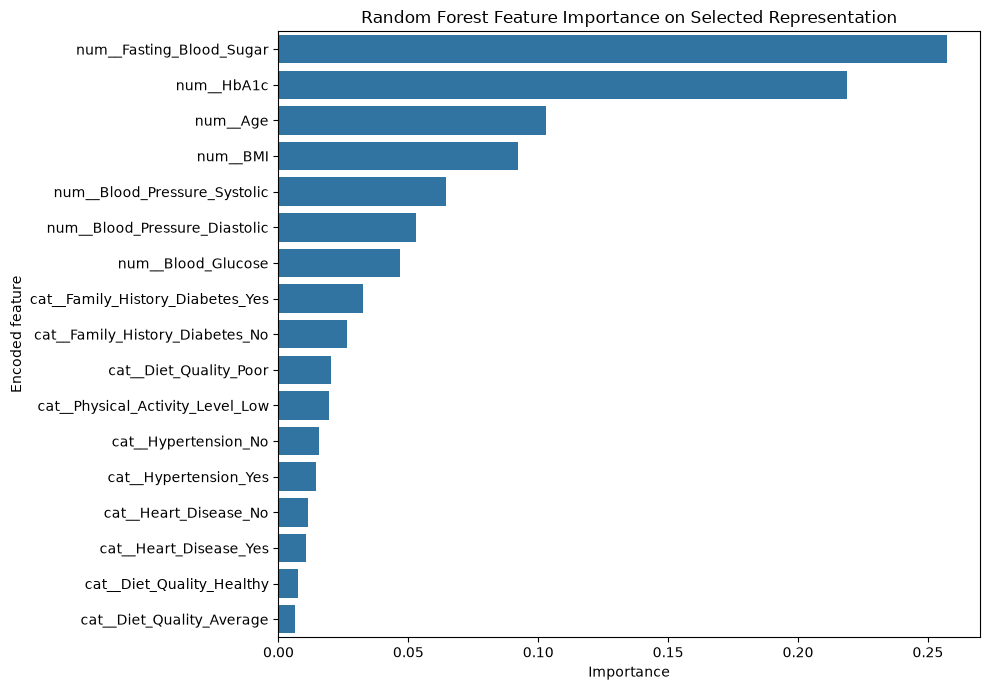

In [75]:
rf_artifact = final_ml_artifacts["Random Forest"]
rf_model = rf_artifact["model"]

rf_importance = pd.DataFrame({
    "feature": final_preprocessor.get_feature_names_out()[final_selector.get_support()],
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importance.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=rf_importance.head(20),
    y="feature",
    x="importance",
    orient="h",
)
plt.title("Random Forest Feature Importance on Selected Representation")
plt.xlabel("Importance")
plt.ylabel("Encoded feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "17_random_forest_feature_importance.png", dpi=180)
plt.show()

# 46. Deployment Demonstration

One untouched test patient is used to demonstrate the deployment flow.

The result contains the best ML prediction/probabilities and the Deep Learning prediction/probabilities.


In [76]:
# Take one untouched test row as a deployment-style example.
sample_raw = X_test.iloc[[0]].copy()
sample_actual = y_test.iloc[0]

sample_engineered = add_engineered_features(sample_raw)[FINAL_FEATURES]

sample_ml_pre = final_preprocessor.transform(sample_engineered)
sample_ml_sel = final_selector.transform(sample_ml_pre)

sample_ml_prob = best_ml_artifact["model"].predict_proba(sample_ml_sel)[0]
sample_ml_pred = int(np.argmax(sample_ml_prob))

sample_dl_pre = sample_ml_pre
sample_dl_sel = sample_ml_sel
sample_dl_prob = final_dl_model.predict_proba(sample_dl_sel)[0]
sample_dl_pred = int(np.argmax(sample_dl_prob))

deployment_demo = {
    "actual_class": sample_actual,
    "best_machine_learning_model": best_ml_name_final,
    "machine_learning_prediction": CLASS_ORDER[sample_ml_pred],
    "machine_learning_confidence": float(np.max(sample_ml_prob)),
    "machine_learning_probabilities": {
        CLASS_ORDER[i]: float(sample_ml_prob[i]) for i in range(3)
    },
    "deep_learning_prediction": CLASS_ORDER[sample_dl_pred],
    "deep_learning_confidence": float(np.max(sample_dl_prob)),
    "deep_learning_probabilities": {
        CLASS_ORDER[i]: float(sample_dl_prob[i]) for i in range(3)
    },
}

display(pd.DataFrame([deployment_demo]))
print("Raw patient input:")
display(sample_raw)

,actual_class,best_machine_learning_model,machine_learning_prediction,machine_learning_confidence,machine_learning_probabilities,deep_learning_prediction,deep_learning_confidence,deep_learning_probabilities
0,High,HistGradientBoosting,Moderate,0.736654,"{'Low': 0.007659356665036853, 'Moderate': 0.73...",High,0.52297,"{'Low': 0.016074046770507913, 'Moderate': 0.46..."


Raw patient input:


,Age,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,Family_History_Diabetes,Hypertension,Heart_Disease,Diet_Quality,Physical_Activity_Level,Pulse_Pressure,Chol_HDL_Ratio
26277,22.0,36.2,68.9,241.0,10.1,98.7,37.5,117,97,273.1,84.7,Yes,No,Yes,Healthy,Low,20,3.224321


# 47. Persist the Best ML Model

The best ML deployment artifact stores the preprocessing, selector, model, feature definitions, and target class order.

This guarantees that inference uses the same transformation as training.


In [77]:
best_ml_bundle = {
    "task": "multi_class_diabetes_risk_classification",
    "model_name": best_ml_name_final,
    "preprocessor": final_preprocessor,
    "selector": final_selector,
    "model": best_ml_artifact["model"],
    "raw_features": FINAL_FEATURES,
    "numeric_features": numeric_features_final,
    "categorical_features": categorical_features_final,
    "classes": CLASS_ORDER,
    "engineered_features": [
        "Pulse_Pressure",
        "Chol_HDL_Ratio",
    ],
    "feature_selection_percentile": 70,
    "random_seed": SEED,
}

BEST_ML_PATH = MODEL_DIR / "diabetes_best_ml_bundle.joblib"
joblib.dump(best_ml_bundle, BEST_ML_PATH)

print("Saved:", BEST_ML_PATH)

Saved: model\diabetes_best_ml_bundle.joblib


# 48. Persist the Deep Learning Model

The NumPy neural network is saved with its weights, architecture/configuration, preprocessing, and feature-selection artifacts.


In [78]:
DL_WEIGHTS_PATH = MODEL_DIR / "diabetes_dl_weights.npz"
DL_CONFIG_PATH = MODEL_DIR / "diabetes_dl_config.json"
DL_PREPROCESSOR_PATH = MODEL_DIR / "diabetes_dl_preprocessor.joblib"
DL_SELECTOR_PATH = MODEL_DIR / "diabetes_dl_selector.joblib"

final_dl_model.save_weights(DL_WEIGHTS_PATH)

joblib.dump(final_preprocessor, DL_PREPROCESSOR_PATH)
joblib.dump(final_selector, DL_SELECTOR_PATH)

dl_config = {
    "task": "multi_class_diabetes_risk_classification",
    "model_name": "Deep Learning - NumPy MLP",
    "input_dim": int(Xtrv_sel.shape[1]),
    "hidden1": DL_HIDDEN_1,
    "hidden2": DL_HIDDEN_2,
    "output_dim": DL_OUTPUT_DIM,
    "learning_rate": DL_LEARNING_RATE,
    "epochs": DL_EPOCHS,
    "activation_hidden": "ReLU",
    "activation_output": "Softmax",
    "loss": "Multiclass Cross-Entropy",
    "classes": CLASS_ORDER,
    "raw_features": FINAL_FEATURES,
    "engineered_features": [
        "Pulse_Pressure",
        "Chol_HDL_Ratio",
    ],
    "feature_selection_percentile": 70,
    "random_seed": SEED,
}

DL_CONFIG_PATH.write_text(
    json.dumps(dl_config, indent=2),
    encoding="utf-8",
)

print("Saved:")
print(DL_WEIGHTS_PATH)
print(DL_CONFIG_PATH)
print(DL_PREPROCESSOR_PATH)
print(DL_SELECTOR_PATH)

Saved:
model\diabetes_dl_weights.npz
model\diabetes_dl_config.json
model\diabetes_dl_preprocessor.joblib
model\diabetes_dl_selector.joblib


# 49. Save Deployment Metadata

Metadata stores dataset information, selected features, model metrics, Deep Learning configuration, and artifact paths.

Web and Mobile applications load these artifacts instead of retraining.


In [79]:
metadata = {
    "dataset": {
        "name": "Diabetes Risk Prediction Dataset (50K Patients)",
        "filename": DATA_PATH.name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
    },
    "task": {
        "type": "multi_class_classification",
        "target": "Diabetes_Risk",
        "classes": CLASS_ORDER,
    },
    "representation": {
        "raw_feature_count": len(FINAL_FEATURES),
        "encoded_feature_count_before_selection": int(Xtrv_pre.shape[1]),
        "final_model_input_dim": int(Xtrv_sel.shape[1]),
        "train_shape": list(map(int, Xtrv_sel.shape)),
        "test_shape": list(map(int, Xtf_sel.shape)),
    },
    "feature_engineering": {
        "dropped_columns": LEAKAGE_OR_IRRELEVANT[:-1],
        "engineered_features": ["Pulse_Pressure", "Chol_HDL_Ratio"],
        "selected_raw_features": FINAL_FEATURES,
        "selection_method": "Mutual information on training data after one-hot encoding",
        "selection_percentile": 70,
    },
    "best_machine_learning": {
        "model": best_ml_name_final,
        "metrics": {
            k: float(v) for k, v in best_ml_metrics.items()
        },
        "artifact": str(BEST_ML_PATH),
    },
    "deep_learning": {
        "model": "NumPy MLP",
        "architecture": [
            int(Xtrv_sel.shape[1]),
            DL_HIDDEN_1,
            DL_HIDDEN_2,
            DL_OUTPUT_DIM,
        ],
        "learning_rate": DL_LEARNING_RATE,
        "epochs": DL_EPOCHS,
        "metrics": {
            k: float(v) for k, v in final_dl_metrics.items()
            if k != "Model"
        },
        "weights": str(DL_WEIGHTS_PATH),
        "config": str(DL_CONFIG_PATH),
    },
    "four_model_comparison": comparison_df.to_dict(orient="records"),
    "visualizations_directory": str(FIG_DIR),
    "random_seed": SEED,
}

METADATA_PATH = MODEL_DIR / "diabetes_metadata.json"
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved:", METADATA_PATH)

Saved: model\diabetes_metadata.json


# 50. Deployment-Ready Inference Function

The deployment flow is:

**Raw patient input → feature engineering → saved preprocessing → saved selector → Best ML + Deep Learning → prediction + probabilities**


In [80]:
ENGINEERED_FEATURES = ["Pulse_Pressure", "Chol_HDL_Ratio"]
RAW_DEPLOYMENT_FEATURES = [
    c for c in FINAL_FEATURES
    if c not in ENGINEERED_FEATURES
]

def predict_both_models(raw_patient_dict):
    input_df = pd.DataFrame([raw_patient_dict])

    # The user/mobile app sends only raw model-input fields.
    # Engineered fields are created here using the same logic as training.
    missing_required = [
        c for c in RAW_DEPLOYMENT_FEATURES
        if c not in input_df.columns
    ]
    if missing_required:
        raise ValueError(
            f"Missing required raw fields: {missing_required}"
        )

    input_engineered = add_engineered_features(input_df)

    missing_after_engineering = [
        c for c in FINAL_FEATURES
        if c not in input_engineered.columns
    ]
    if missing_after_engineering:
        raise ValueError(
            f"Could not create required features: {missing_after_engineering}"
        )

    input_engineered = input_engineered[FINAL_FEATURES]

    # Best ML path
    ml_pre = best_ml_bundle["preprocessor"].transform(input_engineered)
    ml_sel = best_ml_bundle["selector"].transform(ml_pre)
    ml_prob = best_ml_bundle["model"].predict_proba(ml_sel)[0]
    ml_pred = int(np.argmax(ml_prob))

    # Deep Learning path
    dl_pre = final_preprocessor.transform(input_engineered)
    dl_sel = final_selector.transform(dl_pre)
    dl_prob = final_dl_model.predict_proba(dl_sel)[0]
    dl_pred = int(np.argmax(dl_prob))

    return {
        "best_machine_learning_model": best_ml_bundle["model_name"],
        "machine_learning_prediction": CLASS_ORDER[ml_pred],
        "machine_learning_confidence": float(np.max(ml_prob)),
        "machine_learning_probabilities": {
            CLASS_ORDER[i]: float(ml_prob[i]) for i in range(3)
        },
        "deep_learning_prediction": CLASS_ORDER[dl_pred],
        "deep_learning_confidence": float(np.max(dl_prob)),
        "deep_learning_probabilities": {
            CLASS_ORDER[i]: float(dl_prob[i]) for i in range(3)
        },
    }

print("Deployment inference function is ready.")


Deployment inference function is ready.


# 51. Reproducibility Check

The notebook records the random seed, split strategy, selected features, model configuration, Deep Learning architecture, training settings, and saved artifacts.


In [81]:
reproducibility = {
    "random_seed": SEED,
    "split": "70% train / 15% validation / 15% test",
    "stratified": True,
    "target": "Diabetes_Risk",
    "ml_models": list(models.keys()),
    "best_ml_model": best_ml_name_final,
    "deep_learning_architecture": f"{Xtrv_sel.shape[1]} -> {DL_HIDDEN_1} -> {DL_HIDDEN_2} -> {DL_OUTPUT_DIM}",
    "deep_learning_learning_rate": DL_LEARNING_RATE,
    "deep_learning_epochs": DL_EPOCHS,
    "deep_learning_framework": "None - NumPy only",
    "saved_artifacts": [
        str(BEST_ML_PATH),
        str(DL_WEIGHTS_PATH),
        str(DL_CONFIG_PATH),
        str(DL_PREPROCESSOR_PATH),
        str(DL_SELECTOR_PATH),
        str(METADATA_PATH),
    ],
}

display(pd.DataFrame({
    "Parameter": list(reproducibility.keys()),
    "Value": [reproducibility[k] for k in reproducibility.keys()],
}))

,Parameter,Value
0,random_seed,42
1,split,70% train / 15% validation / 15% test
2,stratified,True
3,target,Diabetes_Risk
4,ml_models,"[Logistic Regression, Random Forest, HistGradi..."
5,best_ml_model,HistGradientBoosting
6,deep_learning_architecture,17 -> 64 -> 32 -> 3
7,deep_learning_learning_rate,0.01
8,deep_learning_epochs,300
9,deep_learning_framework,None - NumPy only


# 52. Final Conclusion

### What was learned?

1. Data quality and leakage control are essential before training.
2. Feature engineering converts raw patient information into a useful numerical representation.
3. Class imbalance makes Macro F1, Precision, and Recall important alongside accuracy.
4. Three classical ML models can be compared fairly with the NumPy Deep Learning model using the same test set.
5. The NumPy implementation demonstrates forward propagation, loss, backpropagation, and gradient descent.
6. Deployment must reuse the same preprocessing and feature-selection logic learned during training.

### Final system

```text
Raw patient input
      ↓
Feature engineering
      ↓
Saved preprocessing + selector
      ↓
 ┌───────────────┬──────────────────┐
 ↓               ↓
Best ML          Deep Learning
 ↓               ↓
Prediction       Prediction
Probability      Probability
 └───────────────┴──────────────────┘
              ↓
        Web / Mobile UI
```


## Web
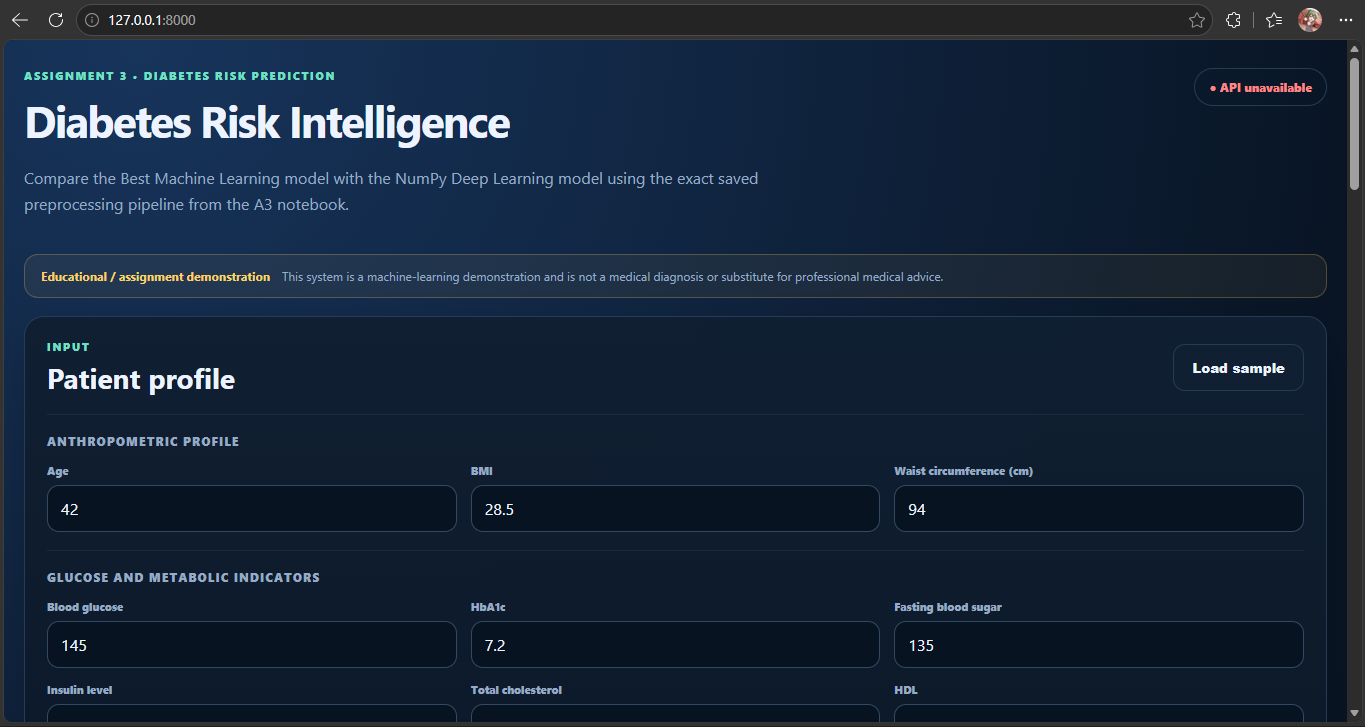
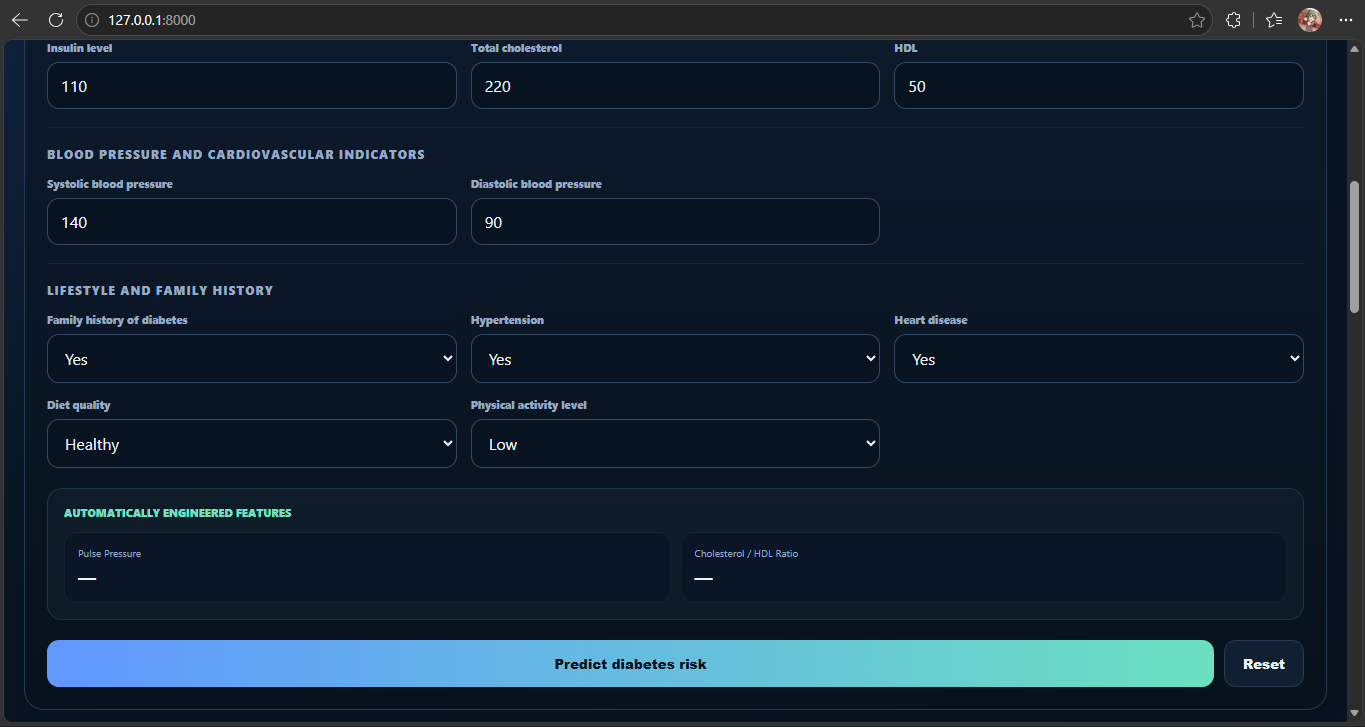
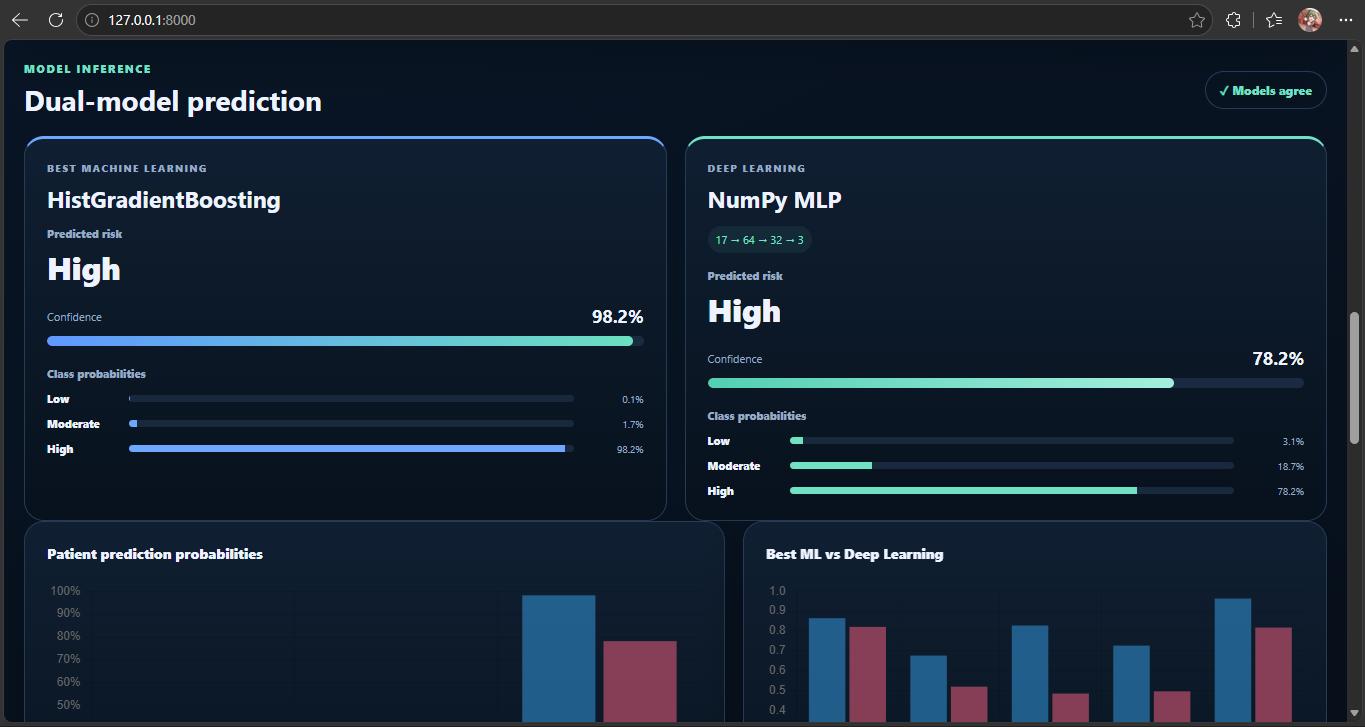
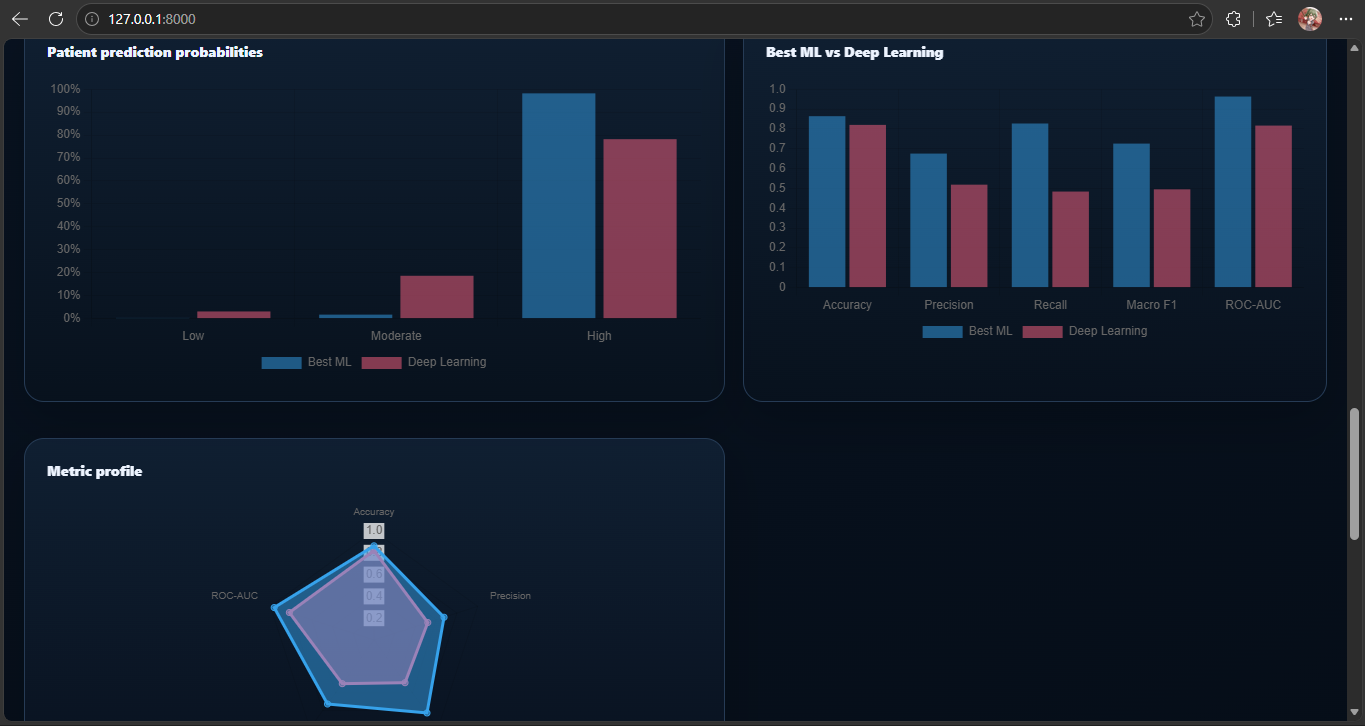
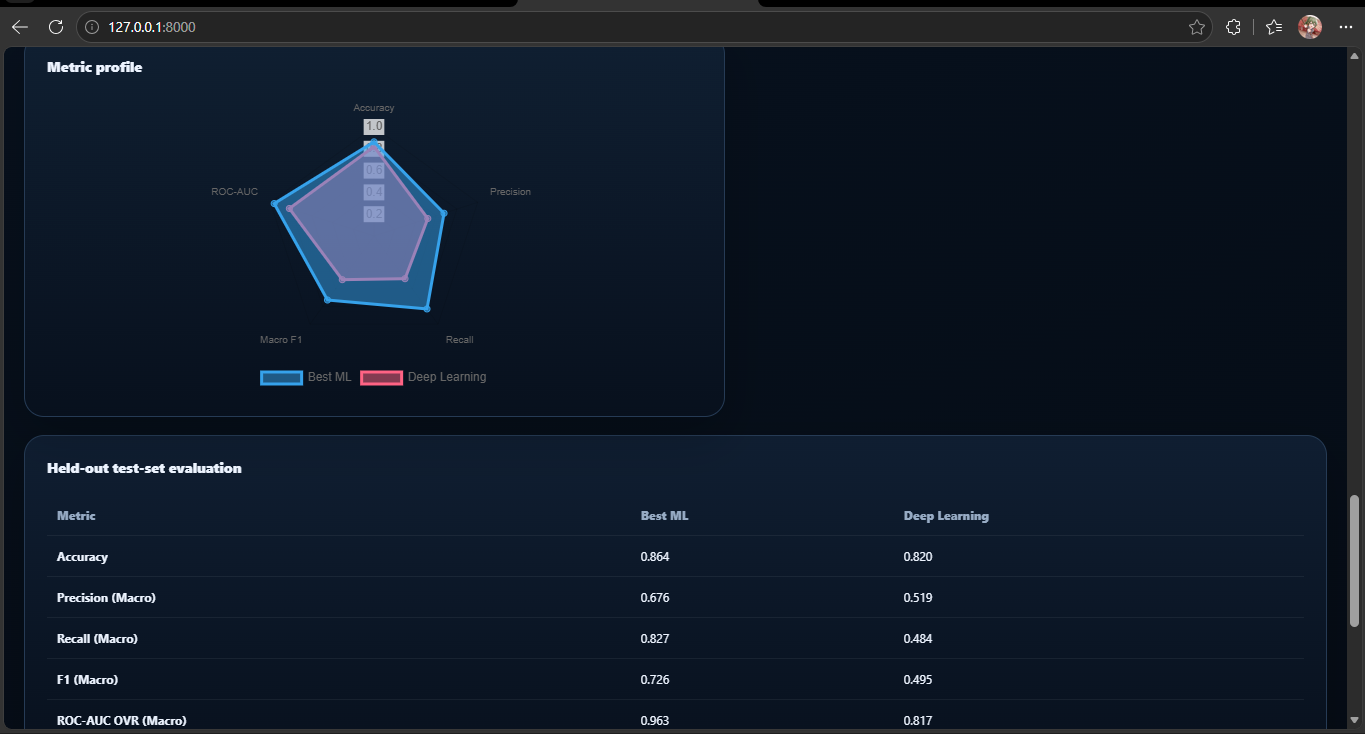
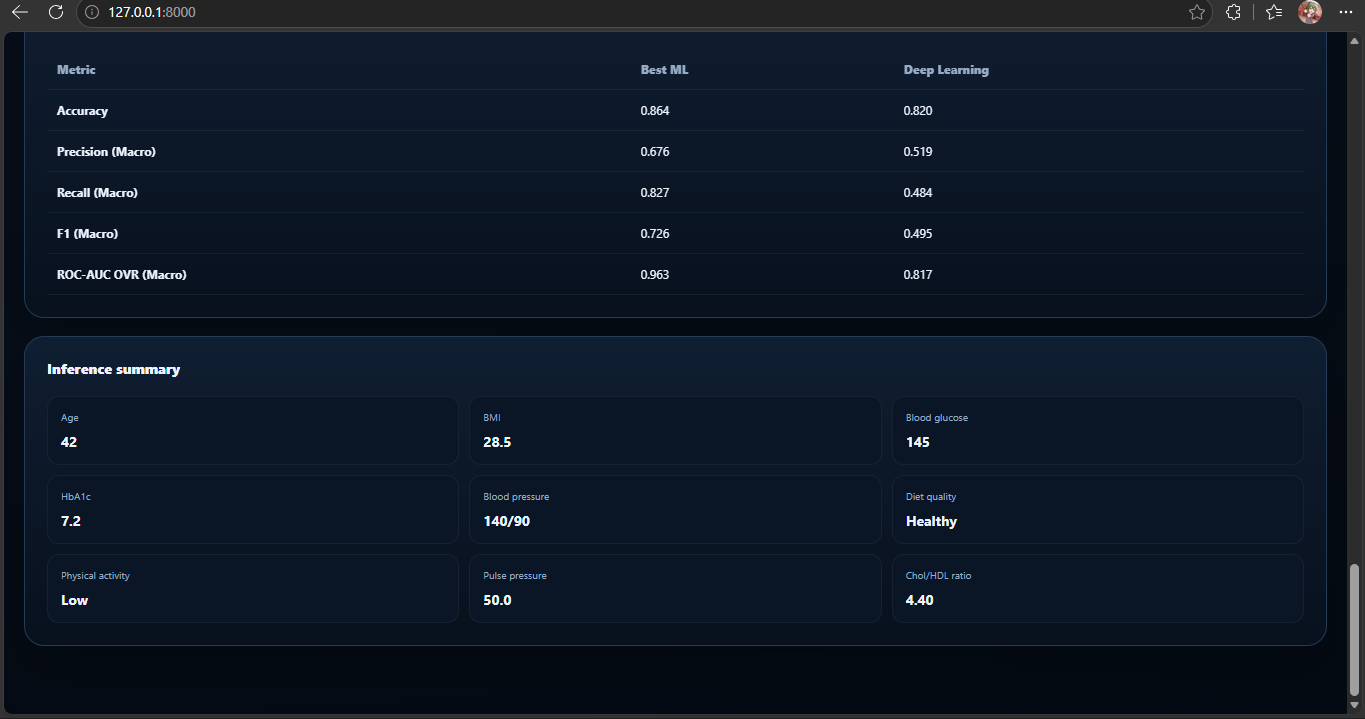